[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/magrilu/cv-dojo/blob/main/notebooks/geometry/fitting-a-conic.ipynb)

# Fitting a conic

Conic fitting is a very convenient playground for training in geometric estimation. It is a task rich enough to contain most of the issues that will come back later, but simple enough that we can draw almost everything in the plane.

We will use conic fitting to present two themes:

1. **Direct linear transform algorithm**
2. **Sampson error to measure residuals in geometric estimation problmes**

We will start with high-school algebra, pass through projective geometry, and end with the first-order geometric residual that we will later meet again in two-view geometry.

In [1]:
#| echo: false
import sys, subprocess
from pathlib import Path

if "google.colab" in sys.modules and not Path("cv-dojo").exists():
    subprocess.run(["git", "clone", "-q", "--depth", "1",
                    "https://github.com/magrilu/cv-dojo.git"], check=True)
    import os
    os.chdir("cv-dojo")

for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "src" / "cvdojo").exists():
        sys.path.insert(0, str(parent / "src")); break

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import polynomial as Pn
from scipy.optimize import least_squares

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": False})

ACCENT, BLUE, GREY, RED = "#F29105", "#3288BD", "0.45", "#D53E4F"
A_TRUE, B_TRUE = 200.0, 120.0
SIGMA = 1.0

##  A conic is a projective point in $\mathbb{P}^5$

A quick recap: a conic is the zero set of a quadratic polynomial in two variables,

$$
f(x,y)=ax^2+bxy+cy^2+dx+ey+f=0,
$$ {#eq-conic}

or, in homogeneous coordinates $\widetilde{\mathbf x}=(x,y,1)^\top$,

$$
\widetilde{\mathbf x}^{\top}\mathsf C\widetilde{\mathbf x}=0,
\qquad
\mathsf C=
\begin{bmatrix}
a & b/2 & d/2\\
b/2 & c & e/2\\
d/2 & e/2 & f
\end{bmatrix}.
$$

It is often convenient to stack the six independent coefficients into

$$
\mathbf c=(a,b,c,d,e,f)^\top\in\mathbb R^6.
$$

But $\mathbf c$ and $\lambda\mathbf c$, for every $\lambda\neq0$, describe exactly the same curve. The coefficients therefore represent a point of the projective space $\mathbb P^5$, and a conic has five degrees of freedom.

Two simple algebraic tests will be useful later. The sign of $b^2-4ac$ distinguishes the usual non-degenerate types, while

$$
\det(\mathsf C)=0
$$

marks a **degenerate conic**, for example a pair of lines. We will actually meet three such conics in a moment.

In [2]:
def conic_matrix(v):
    """Build the symmetric matrix C from (a,b,c,d,e,f)."""
    a, b, c, d, e, f = np.asarray(v, float)
    return np.array([[a, b/2, d/2],
                     [b/2, c, e/2],
                     [d/2, e/2, f]])


def conic_vector(C):
    return np.array([C[0,0], 2*C[0,1], C[1,1],
                     2*C[0,2], 2*C[1,2], C[2,2]])


def conic_value(C, P):
    """Evaluate f at points stored row-wise in P."""
    P = np.atleast_2d(P)
    h = np.c_[P, np.ones(len(P))]
    return np.einsum("ni,ij,nj->n", h, C, h)


def conic_grad(C, P):
    """Gradient of f with respect to the Cartesian coordinates (x,y)."""
    P = np.atleast_2d(P)
    h = np.c_[P, np.ones(len(P))]
    return 2 * (h @ C)[:, :2]


def conic_type(C, tol=1e-11):
    if abs(np.linalg.det(C)) < tol * max(1.0, np.linalg.norm(C)**3):
        return "degenerate"
    disc = C[0,1]**2 - C[0,0]*C[1,1]
    if abs(disc) < tol:
        return "parabola"
    return "hyperbola" if disc > 0 else "ellipse"


def conic_axes(C):
    """Semi-axes if C is a real ellipse; otherwise None."""
    A, b, c0 = C[:2,:2], C[:2,2], C[2,2]
    try:
        ctr = -np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        return None
    k = ctr @ A @ ctr - c0
    w = np.linalg.eigvalsh(A / k)
    if np.any(w <= 0):
        return None
    return np.sort(1/np.sqrt(w))[::-1]


def value_grid(C, xlim, ylim, n=400):
    gx, gy = np.meshgrid(np.linspace(*xlim, n), np.linspace(*ylim, n))
    G = np.stack([gx, gy, np.ones_like(gx)])
    F = np.einsum("ihw,ij,jhw->hw", G, C, G)
    return gx, gy, F


C_TRUE = conic_matrix([1/A_TRUE**2, 0, 1/B_TRUE**2, 0, 0, -1.0])
C_TRUE /= np.linalg.norm(C_TRUE)
LIM = ((-280, 280), (-210, 210))

print("running example:", conic_type(C_TRUE),
      "with semi-axes", conic_axes(C_TRUE).round(1), "pixels")

running example: ellipse with semi-axes [200. 120.] pixels


## DLT is a null-space problem

The important observation is that Equation [-@eq-conic] is quadratic in the point coordinates but **linear in the conic coefficients**. A measured point $\mathbf p_i=(x_i,y_i)$ contributes one equation

$$
\begin{bmatrix}
x_i^2 & x_i y_i & y_i^2 & x_i & y_i & 1
\end{bmatrix}\mathbf c=0.
$$

Stacking $N$ points gives the homogeneous linear system

$$
\mathsf A\mathbf c=0,
$$

where $\mathsf A$ is the **design matrix**. The whole solution set is therefore a vector space: the null space of $\mathsf A$.

The key bookkeeping identity is

$$
\dim\ker\mathsf A=6-\operatorname{rank}(\mathsf A).
$$

The rank tells us how many independent constraints the data provide; the nullity tells us how much freedom is left in the model.

In [3]:
def design_matrix(P):
    x, y = P[:,0], P[:,1]
    return np.column_stack([x*x, x*y, y*y, x, y, np.ones(len(P))])


def normalize_points(P):
    """Hartley-style normalization: centroid at zero, mean radius sqrt(2)."""
    ctr = P.mean(axis=0)
    scale = np.sqrt(2) / np.linalg.norm(P-ctr, axis=1).mean()
    T = np.array([[scale, 0, -scale*ctr[0]],
                  [0, scale, -scale*ctr[1]],
                  [0, 0, 1.0]])
    Xh = (T @ np.c_[P, np.ones(len(P))].T).T
    return Xh[:,:2], T


def fit_dlt(P, normalize=True):
    X, T = normalize_points(P) if normalize else (P, np.eye(3))
    _, _, Vt = np.linalg.svd(design_matrix(X))
    Cn = conic_matrix(Vt[-1])
    C = T.T @ Cn @ T
    return C / np.linalg.norm(C)


t5 = np.deg2rad([20, 85, 150, 225, 310])
P5 = np.column_stack([A_TRUE*np.cos(t5), B_TRUE*np.sin(t5)])
A5 = design_matrix(P5)

print("five points")
print("  design matrix shape :", A5.shape)
print("  rank                :", np.linalg.matrix_rank(A5))
print("  null-space dimension:", 6-np.linalg.matrix_rank(A5))

C5 = fit_dlt(P5)
print("  recovered semi-axes :", conic_axes(C5).round(3))

five points
  design matrix shape : (5, 6)
  rank                : 5
  null-space dimension: 1
  recovered semi-axes : [200. 120.]


For five points in general position the rank is five, so the null space is one-dimensional. There are infinitely many coefficient vectors in that line, but they differ only by scale: in $\mathbb P^5$ they are **one conic**.

In practice we should not build $\mathsf A$ directly from large pixel coordinates. The columns contain $x^2$ next to a column of ones, so the system is badly scaled. We use the same short preconditioning trick as in the eight-point algorithm: translate the points to zero mean and rescale their mean distance to $\sqrt2$, fit there, then transform the conic back. This improves numerical conditioning; it does not change the geometry of the problem.

## Four points: a pencil of conics

Now remove one point. With four generic points,

$$
\operatorname{rank}(\mathsf A)=4,
\qquad
\dim\ker\mathsf A=2.
$$

Choose two generators $\mathbf c_0,\mathbf c_1$ of the null space. Every exact solution has the form

$$
\mathbf c(\lambda,\mu)=\lambda\mathbf c_0+\mu\mathbf c_1.
$$

Since the overall scale is irrelevant, $[\lambda:\mu]\in\mathbb P^1$: a two-dimensional vector space of coefficient vectors becomes a **one-parameter family of conics**, called a *pencil*.

In [4]:
P4 = P5[:4]
A4 = design_matrix(P4)
_, _, Vt4 = np.linalg.svd(A4)
N = Vt4[-2:].T                    # columns form a basis of ker A

# For the plots, choose an equivalent basis in which C0 is the true ellipse.
c0 = conic_vector(C_TRUE)
c0 = c0 / np.linalg.norm(c0)
c1 = N[:,0] - c0 * (c0 @ N[:,0])
c1 = c1 / np.linalg.norm(c1)
C0, C1 = conic_matrix(c0), conic_matrix(c1)

print("four points")
print("  rank                :", np.linalg.matrix_rank(A4))
print("  null-space dimension:", 6-np.linalg.matrix_rank(A4))
print("  ||A c0||            :", f"{np.linalg.norm(A4@c0):.2e}")
print("  ||A c1||            :", f"{np.linalg.norm(A4@c1):.2e}")

four points
  rank                : 4
  null-space dimension: 2
  ||A c0||            : 2.48e-16
  ||A c1||            : 2.10e-13


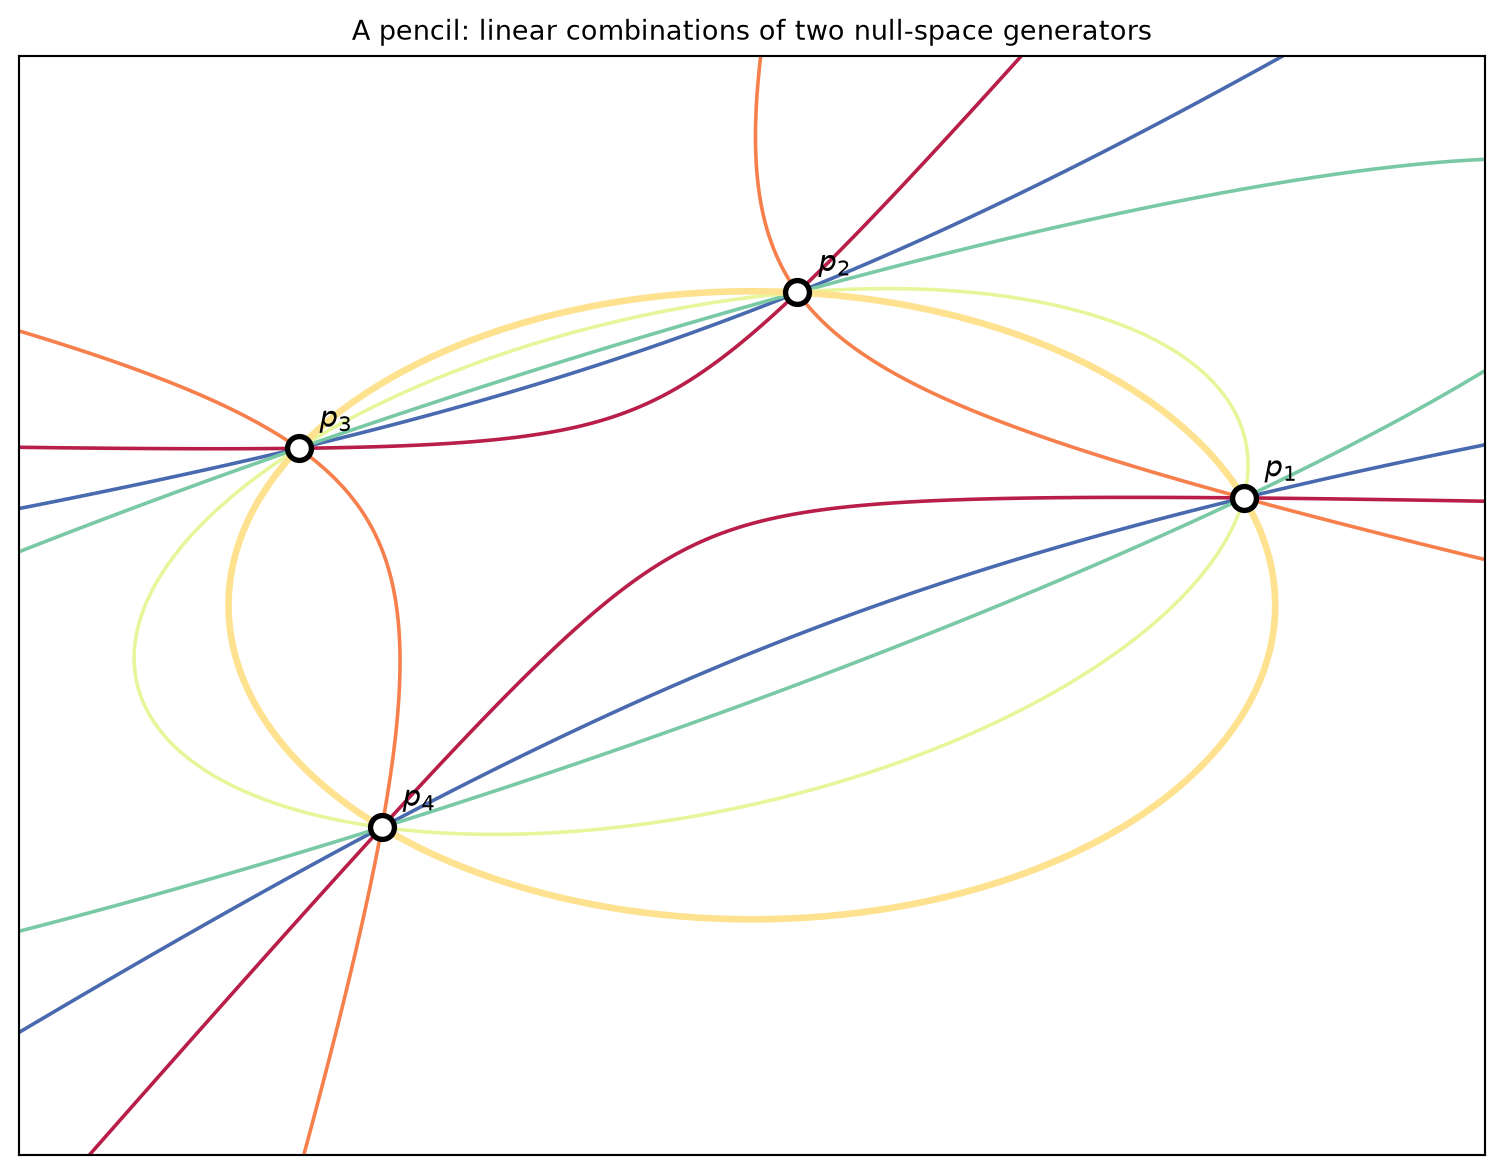

In [5]:
#| echo: false
#| label: fig-conic-pencil
#| fig-cap: >-
#|   A pencil of conics generated by the two-dimensional null space of the four-point design matrix.
#|   Every coloured conic is a different linear combination of the same two generators, and every
#|   one passes through the four fixed points.
#| column: page
fig, ax = plt.subplots(figsize=(8.2, 6.0), layout="constrained")
shown = [-0.050, -0.020, -0.005, 0.0, 0.012, 0.045]
cols = plt.cm.Spectral_r(np.linspace(.05, .95, len(shown)))
for t, col in zip(shown, cols):
    C = C0 + t*C1
    gx, gy, F = value_grid(C, *LIM)
    ax.contour(gx, gy, F, levels=[0], colors=[col],
               linewidths=2.5 if t == 0 else 1.35)
ax.scatter(P4[:,0], P4[:,1], s=80, facecolors="white", edgecolors="k", lw=2, zorder=5)
for i,p in enumerate(P4,1):
    ax.text(p[0]+8, p[1]+8, rf"$p_{i}$", fontsize=11)
ax.set_aspect("equal"); ax.set_xlim(*LIM[0]); ax.set_ylim(*LIM[1])
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("A pencil: linear combinations of two null-space generators", fontsize=10)
plt.show()

There is a particularly nice feature hidden inside this pencil. A member is degenerate exactly when

$$
\det\!\bigl(\mathsf C(\lambda,\mu)\bigr)=0.
$$

The entries of $\mathsf C(\lambda,\mu)$ are linear in $\lambda$ and $\mu$, so its determinant is a homogeneous polynomial of degree three. Hence the pencil contains **three degenerate members, counting multiplicity**.

For four real points in general position, they have an immediate geometric interpretation: there are exactly three ways to pair four points, and each pairing gives a conic made of two lines,

$$
(p_1p_2)\cup(p_3p_4),\qquad
(p_1p_3)\cup(p_2p_4),\qquad
(p_1p_4)\cup(p_2p_3).
$$

Let us recover those three members from the cubic $\det(\mathsf C_0+t\mathsf C_1)=0$ and draw them.

In [6]:
def det_polynomial(C0, C1):
    """Coefficients of det(C0 + t C1), in increasing powers of t."""
    ts = np.array([-2.0, -0.5, 0.75, 2.5])
    ys = np.array([np.linalg.det(C0 + t*C1) for t in ts])
    return Pn.polyfit(ts, ys, 3)


def line_through(p, q):
    return np.cross(np.r_[p,1.0], np.r_[q,1.0])


def line_pair_conic(l, m):
    return 0.5*(np.outer(l,m) + np.outer(m,l))


def projective_gap(C, D):
    c, d = conic_vector(C), conic_vector(D)
    c, d = c/np.linalg.norm(c), d/np.linalg.norm(d)
    return min(np.linalg.norm(c-d), np.linalg.norm(c+d))

coef = det_polynomial(C0, C1)
roots = Pn.polyroots(coef)
roots = np.sort(roots[np.abs(roots.imag)<1e-8].real)

pairs = [((0,1),(2,3)), ((0,2),(1,3)), ((0,3),(1,2))]
pair_C = []
labels = []
for (i,j),(k,l) in pairs:
    Cpair = line_pair_conic(line_through(P4[i],P4[j]), line_through(P4[k],P4[l]))
    pair_C.append(Cpair)
    labels.append(rf"$(p_{i+1}p_{j+1})\cup(p_{k+1}p_{l+1})$")

print("roots of det(C0 + t C1) = 0:", np.round(roots, 6))
print("determinants:", [f"{np.linalg.det(C0+t*C1):.1e}" for t in roots])

roots of det(C0 + t C1) = 0: [-0.0256  0.007   0.0323]
determinants: ['-1.0e-18', '-1.0e-18', '-9.8e-19']


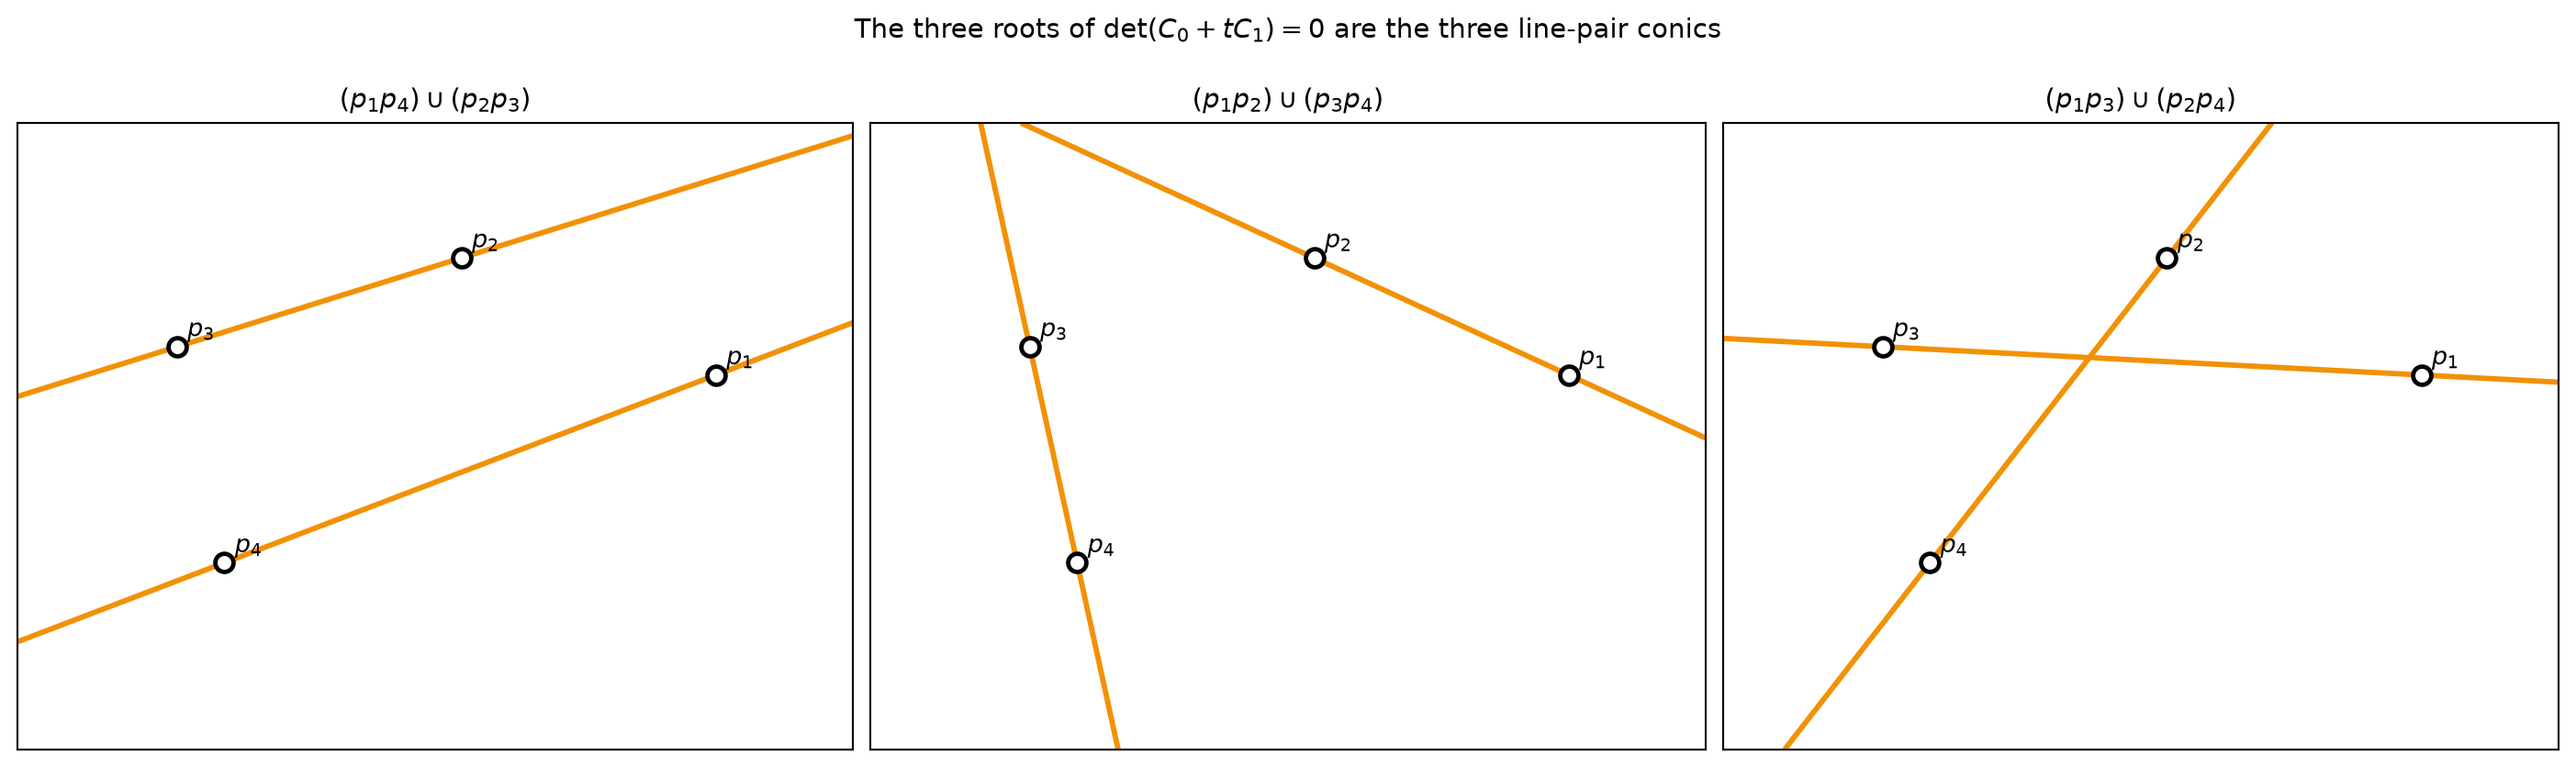

In [7]:
#| echo: false
#| label: fig-degenerate-pencil
#| fig-cap: >-
#|   The three degenerate members of the pencil. The cubic $\det(\mathsf C_0+t\mathsf C_1)=0$
#|   recovers the three possible pairings of four points into two lines.
#| column: page
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.6), layout="constrained")
gx, gy, _ = value_grid(C_TRUE, *LIM)

used=set()
for ax, t in zip(axes, roots):
    Cdeg = C0 + t*C1
    # Match the algebraic root to its geometric line-pair label.
    gaps = [projective_gap(Cdeg, Cp) if j not in used else np.inf for j,Cp in enumerate(pair_C)]
    j = int(np.argmin(gaps)); used.add(j)
    _, _, F = value_grid(Cdeg, *LIM)
    ax.contour(gx, gy, F, levels=[0], colors=[ACCENT], linewidths=2.2)
    ax.scatter(P4[:,0], P4[:,1], s=55, facecolors="white", edgecolors="k", lw=1.8, zorder=5)
    for ii,p in enumerate(P4,1):
        ax.text(p[0]+7, p[1]+7, rf"$p_{ii}$", fontsize=10)
    ax.set_aspect("equal"); ax.set_xlim(*LIM[0]); ax.set_ylim(*LIM[1])
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(labels[j], fontsize=11)
fig.suptitle(r"The three roots of $\det(C_0+tC_1)=0$ are the three line-pair conics", fontsize=11)
plt.show()

This is a useful picture of what the null space means. With four points the algorithm has not failed to choose the right conic: **there is no unique conic to choose**. The data determine a projective line in the space of conics, and even the degenerate line pairs live on that same line.

A fifth generic point contributes one more independent linear constraint and cuts the pencil at one point.

##  Fitting a conic to noisy data

Exact incidence is a clean algebraic statement: $f(\mathbf p)=0$. Real image points do not lie exactly on the model, so before fitting them we should decide what a residual is supposed to measure.

The most direct answer is geometric. Given a measured point $\mathbf p$, let $\mathbf q$ be the closest point on the conic. Then

$$
\boxed{
r_G(\mathbf p,\mathsf C)
=
\min_{\mathbf q:\,f(\mathbf q)=0}
\|\mathbf p-\mathbf q\|.
}
$$ {#eq-geometric-residual}

At a regular closest point, the segment $\mathbf p-\mathbf q$ is normal to the conic,

$$
\mathbf p-\mathbf q \ \parallel\ \nabla f(\mathbf q).
$$

So $r_G$ has the interpretation we would like: it is an actual displacement in the image plane, measured in pixels. The picture is simple even if computing $\mathbf q$ is not.

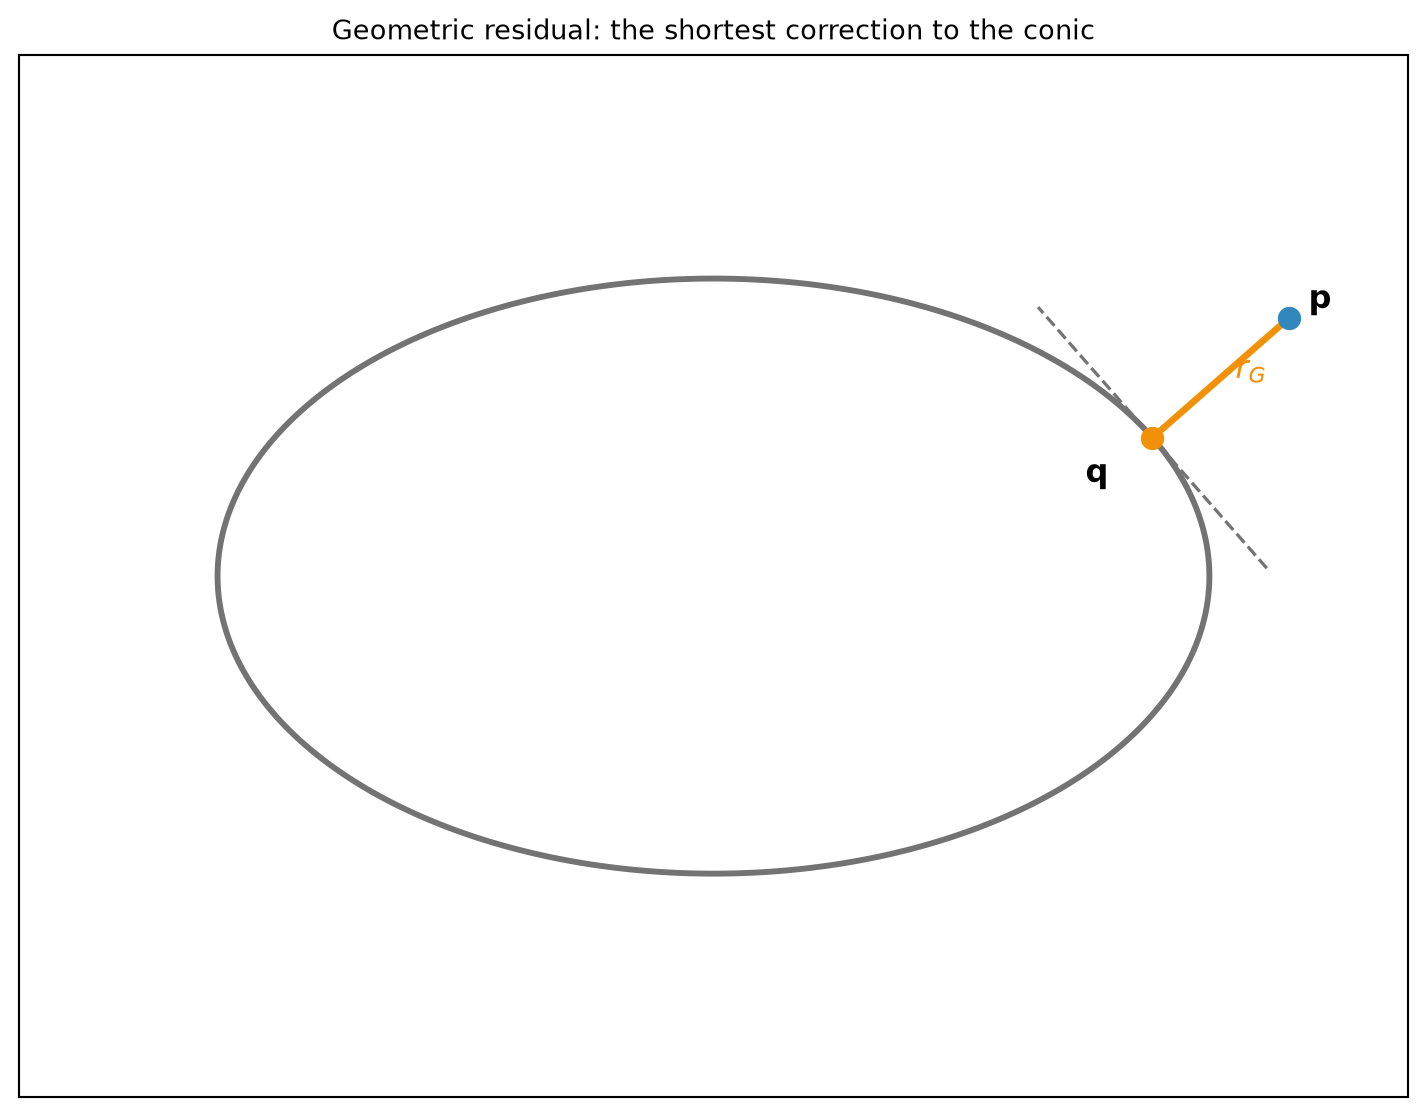

In [8]:
#| echo: false
#| label: fig-geometric-conic-residual
#| fig-cap: >-
#|   The geometric residual $r_G$: $\mathbf q$ is the closest point on the conic to the measurement
#|   $\mathbf p$. At a regular closest point, the correction $\mathbf p-\mathbf q$ is normal to the
#|   conic, hence perpendicular to the dashed tangent.
#| column: page
# Exact closest-point helper for a general conic. The derivation is postponed to Section 7.
def critical_points(C, p):
    A, b, c = C[:2,:2], C[:2,2], C[2,2]
    p = np.asarray(p, float)
    w, R = np.linalg.eigh(A)

    if np.linalg.norm(A@p+b) < 1e-12*(np.linalg.norm(A)+np.linalg.norm(b)):
        ctr = p
        k = ctr@A@ctr - c
        out=[]
        for i in range(2):
            if w[i]/k > 0:
                s = 1/np.sqrt(w[i]/k)
                out += [ctr+s*R[:,i], ctr-s*R[:,i]]
        return np.asarray(out)

    pr, br = R.T@p, R.T@b
    D = [np.array([1.0,w[0]]), np.array([1.0,w[1]])]
    Nn = [np.array([pr[0],-br[0]]), np.array([pr[1],-br[1]])]
    poly = np.zeros(1)
    for i,j in ((0,1),(1,0)):
        poly = Pn.polyadd(poly, w[i]*Pn.polymul(Pn.polymul(Nn[i],Nn[i]), Pn.polymul(D[j],D[j])))
        poly = Pn.polyadd(poly, 2*br[i]*Pn.polymul(Pn.polymul(Nn[i],D[i]), Pn.polymul(D[j],D[j])))
    poly = Pn.polyadd(poly, c*Pn.polymul(Pn.polymul(D[0],D[0]), Pn.polymul(D[1],D[1])))

    out=[]
    for r in Pn.polyroots(poly):
        if abs(r.imag) > 1e-7*max(1.0,abs(r.real)):
            continue
        mu=r.real
        den=1.0+mu*w
        if np.min(np.abs(den))<1e-10:
            continue
        q=R@((pr-mu*br)/den)
        hq=np.r_[q,1.0]
        if abs(hq@C@hq) < 1e-6*np.linalg.norm(C)*(1+q@q):
            out.append(q)
    return np.asarray(out)


def closest_point(C, p):
    Q = critical_points(C, p)
    j = np.argmin(np.linalg.norm(Q-p, axis=1))
    return Q[j]


def geometric_residual(C, P):
    P=np.atleast_2d(P)
    return np.array([np.linalg.norm(p-closest_point(C,p)) for p in P])

p = np.array([232.0, 104.0])
q = closest_point(C_TRUE, p)
gq = conic_grad(C_TRUE, q)[0]
tdir = np.array([-gq[1], gq[0]]) / np.linalg.norm(gq)

fig, ax = plt.subplots(figsize=(7.6, 5.7), layout="constrained")
gx,gy,F=value_grid(C_TRUE,*LIM)
ax.contour(gx,gy,F,levels=[0],colors=[GREY],linewidths=2.2)
ax.plot([p[0],q[0]],[p[1],q[1]],color=ACCENT,lw=2.5)
ax.scatter(*p,s=60,color=BLUE,zorder=5); ax.scatter(*q,s=60,color=ACCENT,zorder=5)
ax.text(p[0]+8,p[1]+4,r"$\mathbf{p}$",fontsize=12)
ax.text(q[0]-27,q[1]-18,r"$\mathbf{q}$",fontsize=12)
L=np.stack([q-70*tdir,q+70*tdir])
ax.plot(L[:,0],L[:,1],"--",color=GREY,lw=1.2)
mid=(p+q)/2
ax.text(mid[0]+6,mid[1],r"$r_G$",color=ACCENT,fontsize=12)
ax.set_aspect("equal"); ax.set_xlim(*LIM[0]); ax.set_ylim(*LIM[1])
ax.set_xticks([]); ax.set_yticks([]); ax.set_title("Geometric residual: the shortest correction to the conic",fontsize=10)
plt.show()

Now return to the linear system. With more than five noisy points there is usually no non-zero vector satisfying $\mathsf A\mathbf c=0$ exactly. The DLT replaces the null-space problem by

$$
\min_{\|\mathbf c\|=1}\|\mathsf A\mathbf c\|^2,
$$

whose solution is the right singular vector associated with the smallest singular value.

But this objective is

$$
\|\mathsf A\mathbf c\|^2
=
\sum_i f(\mathbf p_i)^2.
$$

So DLT minimizes the **algebraic residual**

$$
\boxed{r_A(\mathbf p,\mathsf C)=f(\mathbf p)}
$$

in the coordinate system in which the design matrix is built. This is what keeps the estimate linear. The next question is whether $r_A$ behaves like the geometric residual $r_G$.

## 4. Algebraic error is not a distance

The quickest counterexample is scale. The matrices $\mathsf C$ and $10\mathsf C$ describe the same conic, hence they have the same geometric residual, but

$$
r_A(\mathbf p,10\mathsf C)=10\,r_A(\mathbf p,\mathsf C).
$$

A quantity that can change while the curve does not cannot be a geometric distance.

In [9]:
print("same point, same curve")
print(f"  r_G(p,C)    = {geometric_residual(C_TRUE,p[None,:])[0]:8.3f} px")
print(f"  r_G(p,10 C) = {geometric_residual(10*C_TRUE,p[None,:])[0]:8.3f} px")
print(f"  r_A(p,C)    = {conic_value(C_TRUE,p[None,:])[0]:8.4f}")
print(f"  r_A(p,10 C) = {conic_value(10*C_TRUE,p[None,:])[0]:8.4f}")

same point, same curve
  r_G(p,C)    =   73.085 px
  r_G(p,10 C) =   73.085 px
  r_A(p,C)    =   1.0967
  r_A(p,10 C) =  10.9671


### What does $\nabla f$ mean?

The gradient is not an extra geometric object that we have introduced for Sampson. It is already hidden in the implicit equation of the curve. For the axis-aligned ellipse

$$
f(x,y)=\frac{x^2}{a^2}+\frac{y^2}{b^2}-1,
$$

we have

$$
\nabla f(x,y)=
\begin{bmatrix}
2x/a^2\\[2mm]
2y/b^2
\end{bmatrix}.
$$

At a point $\mathbf q$ on the ellipse, $\nabla f(\mathbf q)$ is perpendicular to the tangent. Indeed, with

$$
\mathbf q(t)=(a\cos t,b\sin t),
\qquad
\mathbf q'(t)=(-a\sin t,b\cos t),
$$

we get

$$
\nabla f(\mathbf q(t))^\top\mathbf q'(t)=0.
$$

So the **direction** of $\nabla f$ is the normal direction to the ellipse. Its **magnitude** tells us how fast the chosen implicit function $f$ changes when we move one pixel in that normal direction:

$$
f(\mathbf q+d\,\mathbf n)
\simeq d\,\|\nabla f(\mathbf q)\|,
\qquad
\mathbf n=\frac{\nabla f(\mathbf q)}{\|\nabla f(\mathbf q)\|}.
$$

For our ellipse,

$$
\|\nabla f(\mathbf q(t))\|
=2\sqrt{\frac{\cos^2t}{a^2}+\frac{\sin^2t}{b^2}},
$$

so it is not constant along the curve: it is smallest at the ends of the major axis and largest at the ends of the minor axis.

This magnitude of $\nabla f$  measures in certain sense the local scale of this particular implicit equation. Equivalently, nearby level sets of $f$ are approximately $|\Delta f|/\|\nabla f\|$ pixels apart. This is exactly the arbitrary local scale that the Sampson denominator will remove.

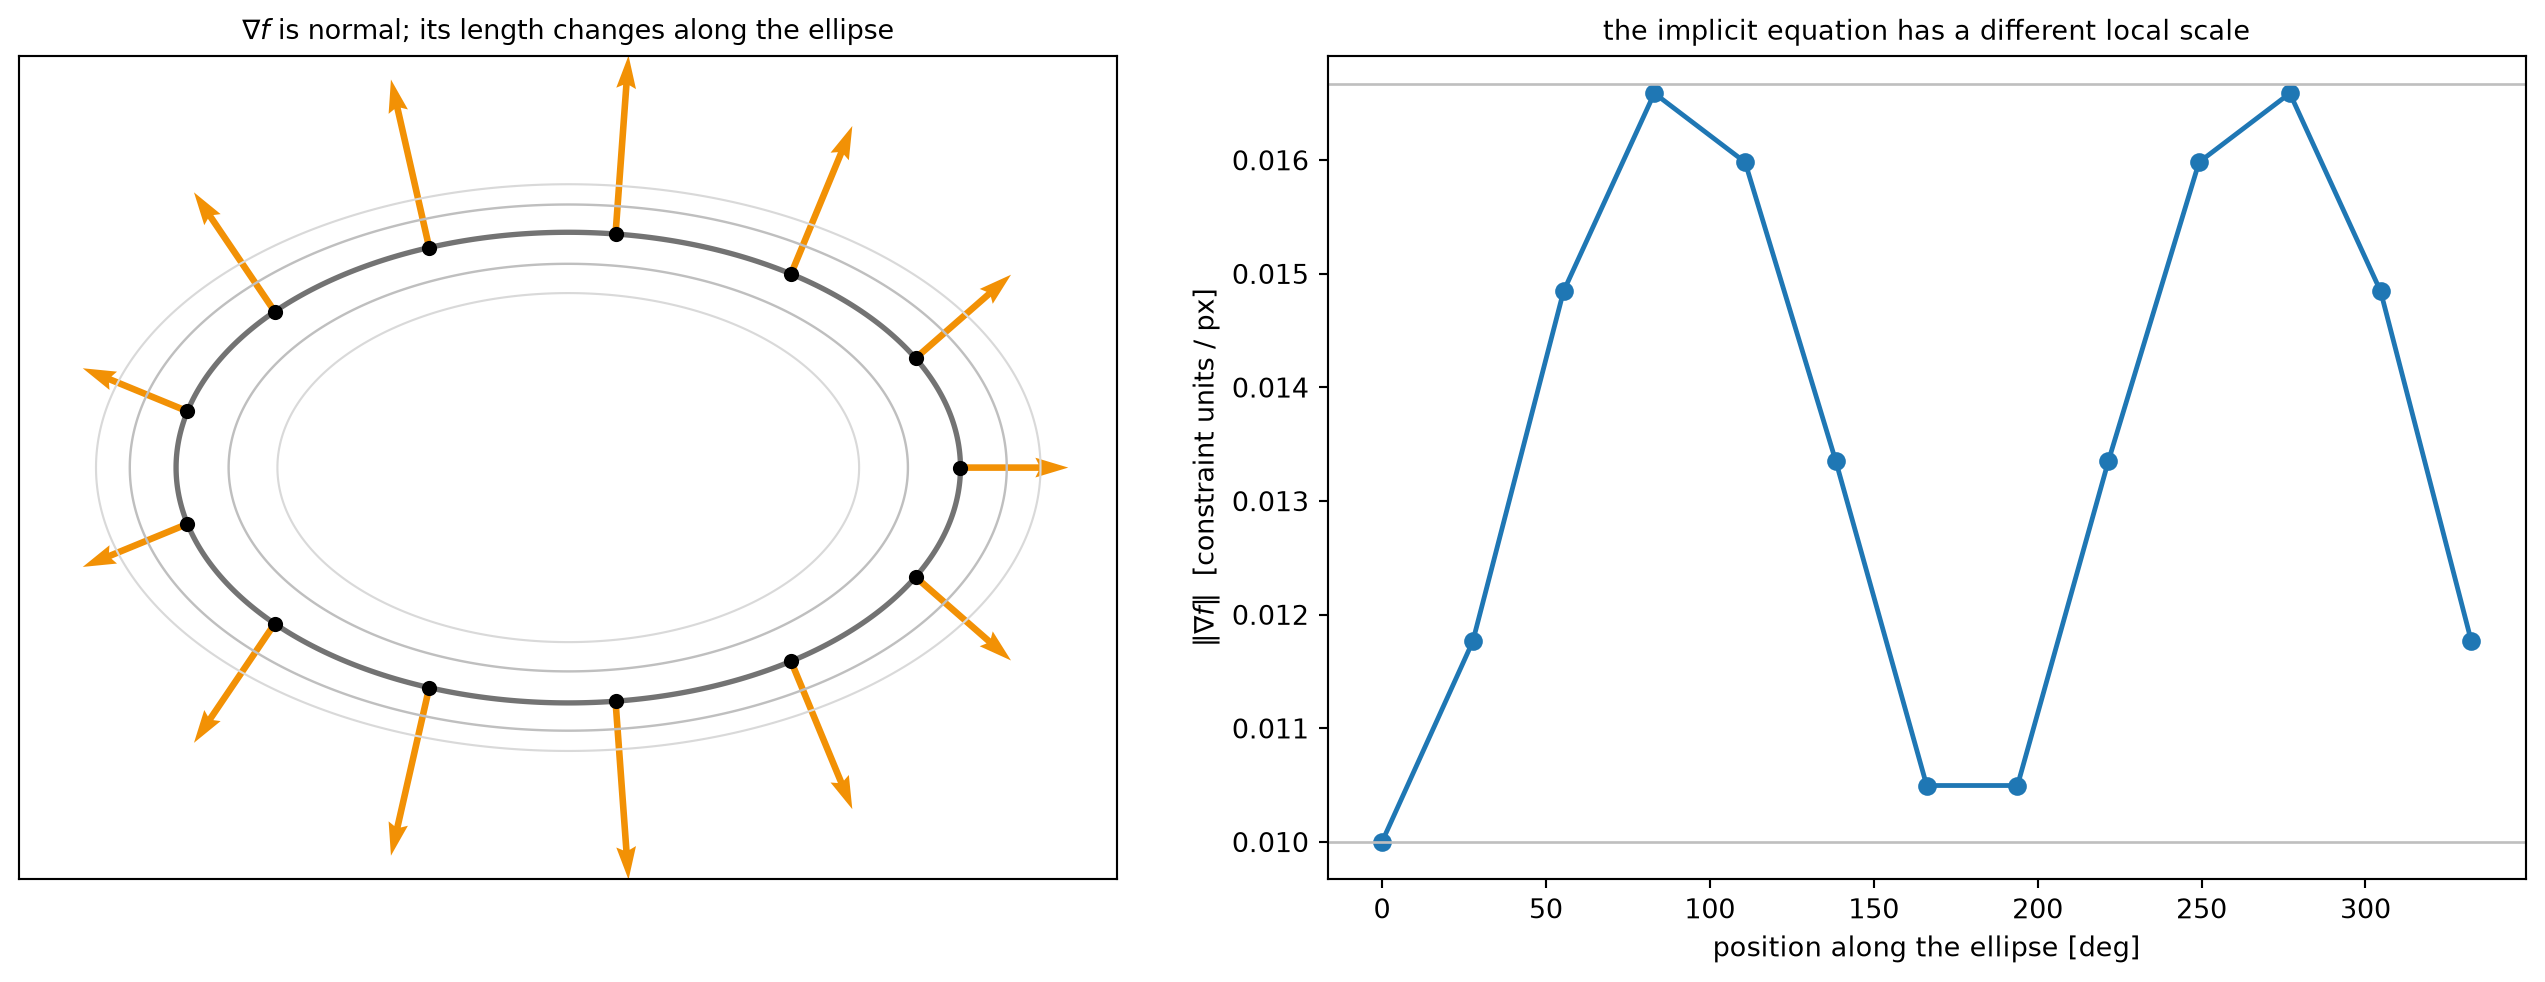

In [10]:
#| echo: false
#| label: fig-conic-gradient
#| fig-cap: >-
#|   What the gradient means on an ellipse. Left: $\nabla f$ is normal to each level set, but its
#|   length changes along the ellipse. Right: $\|\nabla f\|$ records the local scale of the chosen
#|   implicit equation; it is not the curvature of the ellipse.
#| column: page
# Use the unscaled implicit equation x^2/a^2 + y^2/b^2 - 1 = 0
# so that the gradient formula is easy to read.
Cgrad = conic_matrix([1/A_TRUE**2, 0, 1/B_TRUE**2, 0, 0, -1.0])
theta_g = np.linspace(0, 2*np.pi, 13, endpoint=False)
Qg = np.column_stack([A_TRUE*np.cos(theta_g), B_TRUE*np.sin(theta_g)])
Gg = conic_grad(Cgrad, Qg)
mag = np.linalg.norm(Gg, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.0), layout="constrained")

# Left: gradient vectors are normal to the ellipse, with visible relative lengths.
ax = axes[0]
gx, gy, Fg = value_grid(Cgrad, *LIM)
ax.contour(gx, gy, Fg, levels=[-.45, -.25, 0, .25, .45],
           colors=["0.85", "0.75", GREY, "0.75", "0.85"],
           linewidths=[.8, .9, 2.0, .9, .8])
# Scale arrows only for display; relative lengths are the actual gradient magnitudes.
arrow_scale = 5500
ax.quiver(Qg[:,0], Qg[:,1], arrow_scale*Gg[:,0], arrow_scale*Gg[:,1],
          angles="xy", scale_units="xy", scale=1, width=.006, color=ACCENT)
ax.scatter(Qg[:,0], Qg[:,1], s=22, color="k", zorder=4)
ax.set_aspect("equal"); ax.set_xlim(*LIM[0]); ax.set_ylim(*LIM[1])
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(r"$\nabla f$ is normal; its length changes along the ellipse", fontsize=10)

# Right: magnitude around the ellipse.
axes[1].plot(np.rad2deg(theta_g), mag, "o-", lw=1.8)
axes[1].axhline(2/A_TRUE, color="0.75", lw=1)
axes[1].axhline(2/B_TRUE, color="0.75", lw=1)
axes[1].set_xlabel("position along the ellipse [deg]")
axes[1].set_ylabel(r"$\|\nabla f\|$  [constraint units / px]")
axes[1].set_title("the implicit equation has a different local scale", fontsize=10)

plt.show()

Now the failure of the algebraic residual is easy to predict. Start from points $\mathbf q_i$ exactly on the ellipse and move every one of them by the same $15$ pixels along the outward unit normal. Their geometric residual is essentially constant, but to first order

$$
|r_A|=|f(\mathbf q_i+15\,\mathbf n_i)|
\simeq 15\,\|\nabla f(\mathbf q_i)\|.
$$

The same physical displacement therefore produces a different algebraic residual at different places on the same ellipse.

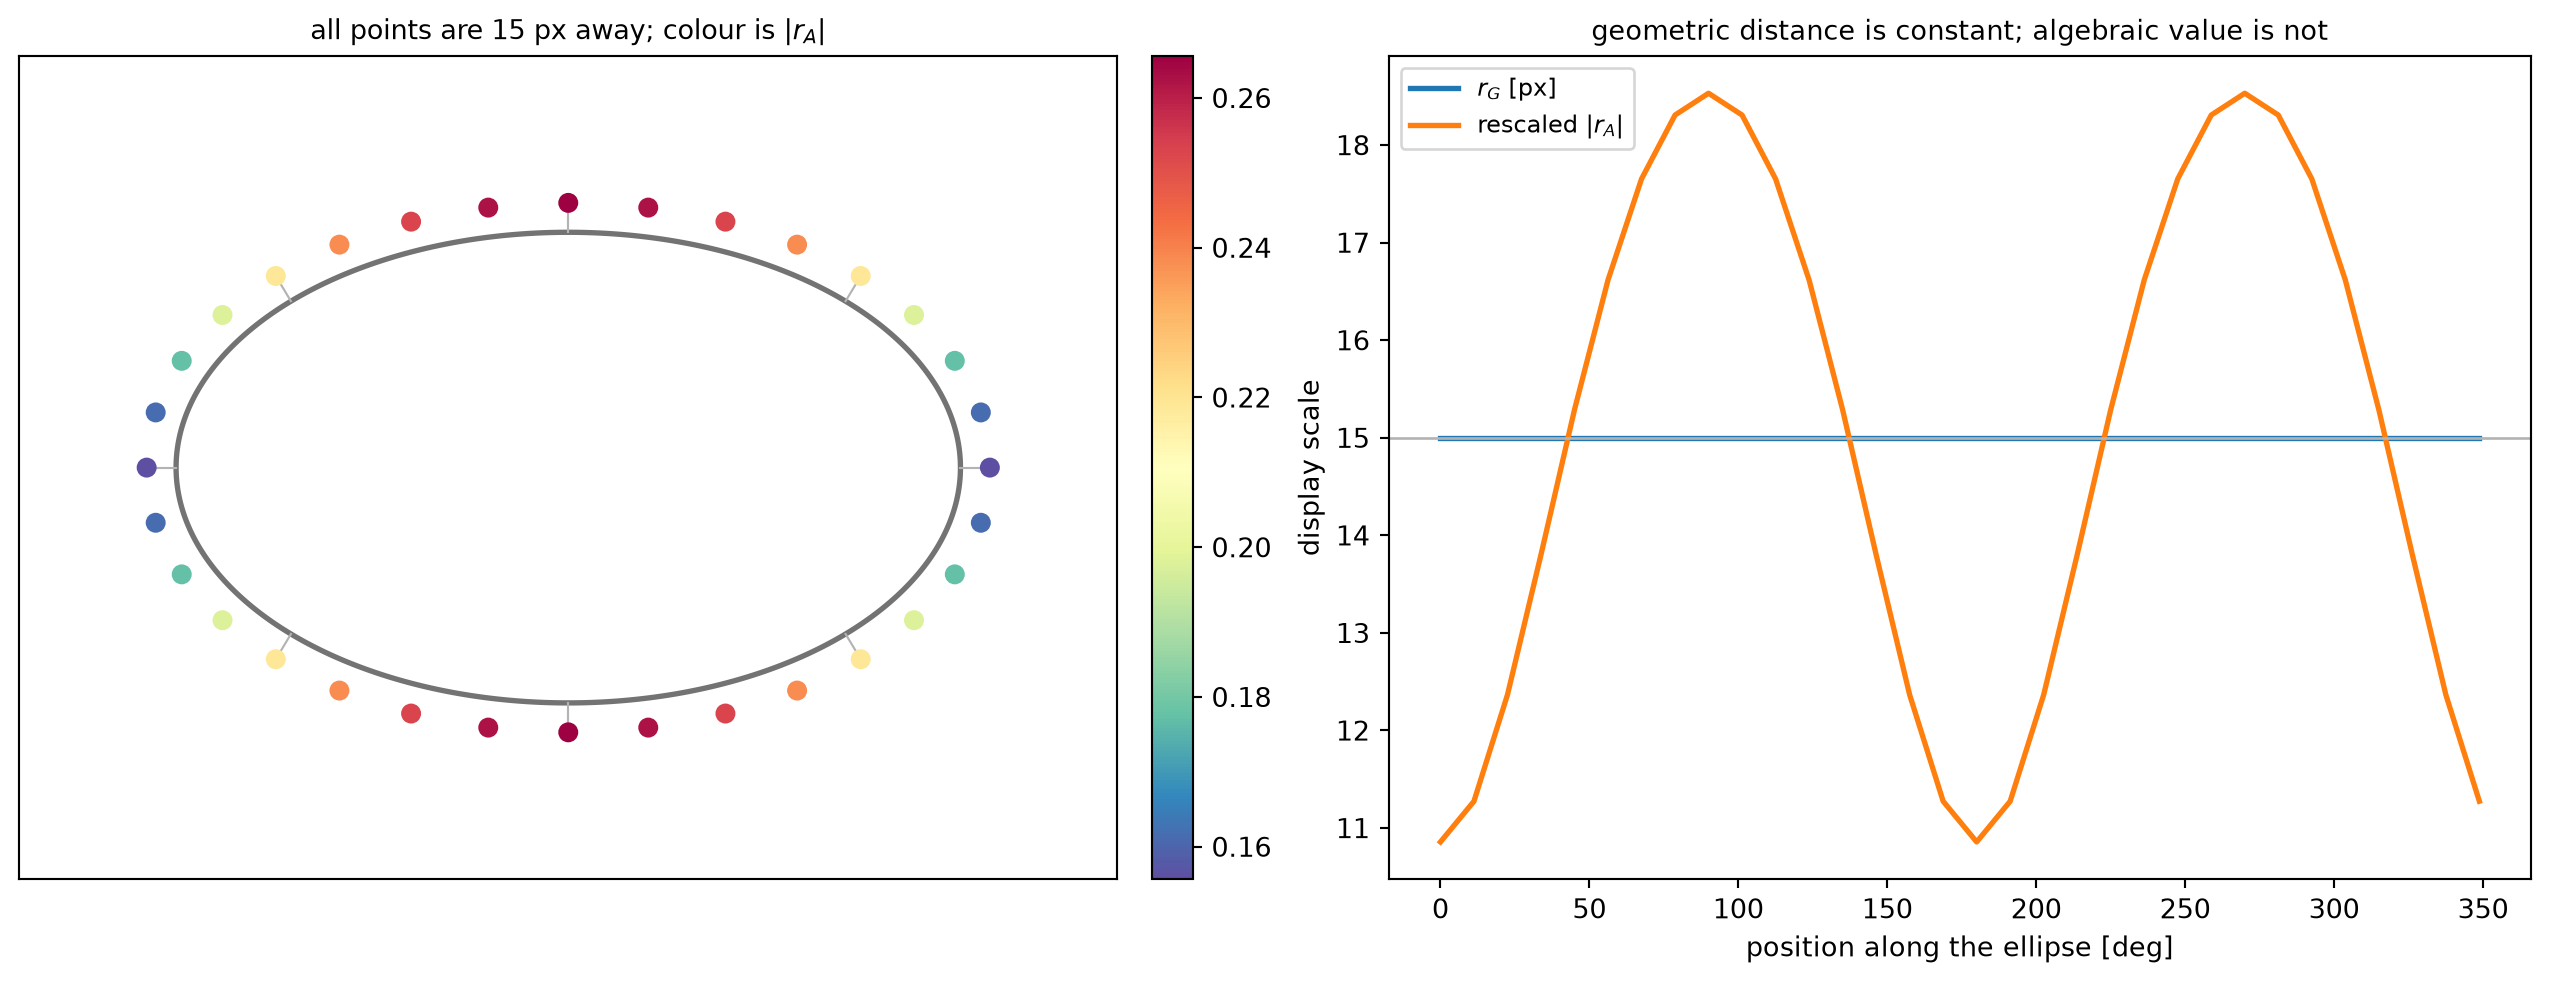

In [11]:
#| echo: false
#| label: fig-algebraic-vs-geometric-conic
#| fig-cap: >-
#|   Equal geometric displacements need not produce equal algebraic residuals. All displayed points
#|   are displaced by 15 pixels along the ellipse normals, yet $|r_A|$ varies because the implicit
#|   function changes at a different rate along the curve.
#| column: page
theta=np.linspace(0,2*np.pi,32,endpoint=False)
Q=np.column_stack([A_TRUE*np.cos(theta),B_TRUE*np.sin(theta)])
G=conic_grad(C_TRUE,Q)
Nrm=G/np.linalg.norm(G,axis=1,keepdims=True)
Poff=Q+15*Nrm
rA=np.abs(conic_value(C_TRUE,Poff))
rG=geometric_residual(C_TRUE,Poff)

fig, axes=plt.subplots(1, 2, figsize=(13.4, 5.0), layout="constrained")
ax=axes[0]
gx,gy,F=value_grid(C_TRUE,*LIM)
ax.contour(gx,gy,F,levels=[0],colors=[GREY],linewidths=2)
sc=ax.scatter(Poff[:,0],Poff[:,1],c=rA,cmap="Spectral_r",s=42,zorder=4)
for q0,p0 in zip(Q[::4],Poff[::4]):
    ax.plot([q0[0],p0[0]],[q0[1],p0[1]],color="0.7",lw=.8)
ax.set_aspect("equal"); ax.set_xlim(*LIM[0]); ax.set_ylim(*LIM[1]); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(r"all points are 15 px away; colour is $|r_A|$",fontsize=10)
plt.colorbar(sc,ax=ax,fraction=.046,pad=.03)

axes[1].plot(np.rad2deg(theta),rG,label=r"$r_G$ [px]",lw=2)
axes[1].plot(np.rad2deg(theta),15*rA/rA.mean(),label=r"rescaled $|r_A|$",lw=2)
axes[1].axhline(15,color="0.7",lw=1)
axes[1].set_xlabel("position along the ellipse [deg]")
axes[1].set_ylabel("display scale")
axes[1].legend(fontsize=9)
axes[1].set_title("geometric distance is constant; algebraic value is not",fontsize=10)
plt.show()

The plot is the numerical version of the previous equation. DLT sees the vertical-axis neighbourhood as more expensive simply because the chosen polynomial changes faster there. The geometry did not assign that preference; the implicit representation did.

This suggests dividing the constraint violation by its local rate of change.

## Sampson from first principles

We would like to find the shortest correction that moves the measured point $\mathbf p$ onto the conic. Writing the corrected point as

$$
\mathbf q=\mathbf p+\boldsymbol\delta,
$$

the exact geometric problem is

$$
\min_{\boldsymbol\delta}\frac12\|\boldsymbol\delta\|^2
\qquad\text{subject to}\qquad
f(\mathbf p+\boldsymbol\delta)=0.
$$

The admissible corrected points $\mathbf q$ lie on the conic itself. This is a projection onto a **curved set**, so solving the problem exactly is nonlinear.

Sampson makes one local simplification: near $\mathbf p$, replace the nonlinear constraint by its first-order linear approximation,

$$
f(\mathbf p+\boldsymbol\delta)
\simeq
f(\mathbf p)+\nabla f(\mathbf p)^\top\boldsymbol\delta.
$$

We therefore solve the simpler problem

$$
\min_{\boldsymbol\delta}\frac12\|\boldsymbol\delta\|^2
\qquad\text{subject to}\qquad
f(\mathbf p)+\nabla f(\mathbf p)^\top\boldsymbol\delta=0.
$$ {#eq-sampson-problem}

The original feasible set was the conic; after linearisation the feasible corrections lie on a line. Finding the shortest correction to that line is easy, but let us derive it rather than memorise the formula.

Introduce a Lagrange multiplier $\lambda$:

$$
\mathcal L(\boldsymbol\delta,\lambda)
=
\frac12\boldsymbol\delta^\top\boldsymbol\delta
+
\lambda\left(f(\mathbf p)+\nabla f(\mathbf p)^\top\boldsymbol\delta\right).
$$

Stationarity with respect to $\boldsymbol\delta$ gives

$$
\nabla_{\boldsymbol\delta}\mathcal L
=
\boldsymbol\delta+\lambda\nabla f(\mathbf p)=0,
$$

hence

$$
\boldsymbol\delta=-\lambda\nabla f(\mathbf p).
$$

Substituting this into the linearised constraint,

$$
f(\mathbf p)-\lambda\|\nabla f(\mathbf p)\|^2=0,
$$

so

$$
\lambda=\frac{f(\mathbf p)}{\|\nabla f(\mathbf p)\|^2}.
$$

Therefore

$$
\boxed{
\boldsymbol\delta_S
=-\frac{f(\mathbf p)}{\|\nabla f(\mathbf p)\|^2}\nabla f(\mathbf p)
}
$$

and the Euclidean distance to this **linearised constraint** is

$$
\boxed{
|r_S(\mathbf p,\mathsf C)|
=\|\boldsymbol\delta_S\|
=\frac{|f(\mathbf p)|}{\|\nabla f(\mathbf p)\|}.
}
$$ {#eq-sampson}

For least-squares fitting we will keep the signed residual

$$
r_S(\mathbf p,\mathsf C)=\frac{f(\mathbf p)}{\|\nabla f(\mathbf p)\|}.
$$

The numerator is the algebraic constraint violation. The denominator converts that local change in constraint value into a displacement in the image plane.

In [12]:
def sampson_residual(C, P):
    g=conic_grad(C,P)
    return conic_value(C,P)/np.linalg.norm(g,axis=1)


def sampson_correction(C, p):
    p=np.asarray(p,float)
    f=conic_value(C,p[None,:])[0]
    g=conic_grad(C,p[None,:])[0]
    delta=-f*g/(g@g)
    return delta, p+delta

pS=np.array([230.0,95.0])
qG=closest_point(C_TRUE,pS)
deltaS,qS=sampson_correction(C_TRUE,pS)
print("for one point:")
print(f"  exact geometric residual |r_G| = {np.linalg.norm(pS-qG):.3f} px")
print(f"  Sampson residual         |r_S| = {np.linalg.norm(deltaS):.3f} px")

for one point:
  exact geometric residual |r_G| = 65.732 px
  Sampson residual         |r_S| = 54.234 px


### The “Sampson myth”

A common shorthand of computer vision folklore says

> *“The Sampson distance is the first-order approximation of the geometric distance.”*

This is close enough to be tempting, but it hides what is actually being approximated.

We do **not** Taylor-expand the true distance function $r_G(\mathbf p)$. Instead, we first replace the nonlinear constraint by its first-order model,

$$
f(\mathbf x)=0
\quad\longrightarrow\quad
f(\mathbf p)+\nabla f(\mathbf p)^\top(\mathbf x-\mathbf p)=0,
$$

and then compute the **exact Euclidean distance from $\mathbf p$ to that affine line**. That exact distance is the Sampson residual.

So a more precise sentence to remember is:

> **Sampson is the exact geometric distance to a first-order model of the constraint.**

Harker and O'Leary called the confusion between these two operations the *myth of Sampsonus*. Near a regular point the linearised constraint is a good local model of the curve, so $|r_S|$ is often close to $r_G$. But the construction tells us exactly what has been approximated: **the constraint set, not the distance function**.

### Where does the linearised constraint live?

The graph of the implicit function makes that distinction visible. Plot

$$
z=f(x,y).
$$

The conic is the intersection of this surface with the plane $z=0$. The image measurement $\mathbf p$ lifts to

$$
P=(p_x,p_y,f(\mathbf p))
$$

on the surface. The tangent plane at $P$ is

$$
z=f(\mathbf p)+\nabla f(\mathbf p)^\top(\mathbf x-\mathbf p).
$$

Its intersection with $z=0$ is

$$
\boxed{
f(\mathbf p)+\nabla f(\mathbf p)^\top(\mathbf x-\mathbf p)=0,
}
$$

exactly the linearised constraint used above. In the 3D panel below the **red line is constructed explicitly as this intersection**. Sampson is the orthogonal projection of $\mathbf p$ onto that red line in the $xy$ plane.

tangent-plane equation evaluated on q_S: -2.22e-16


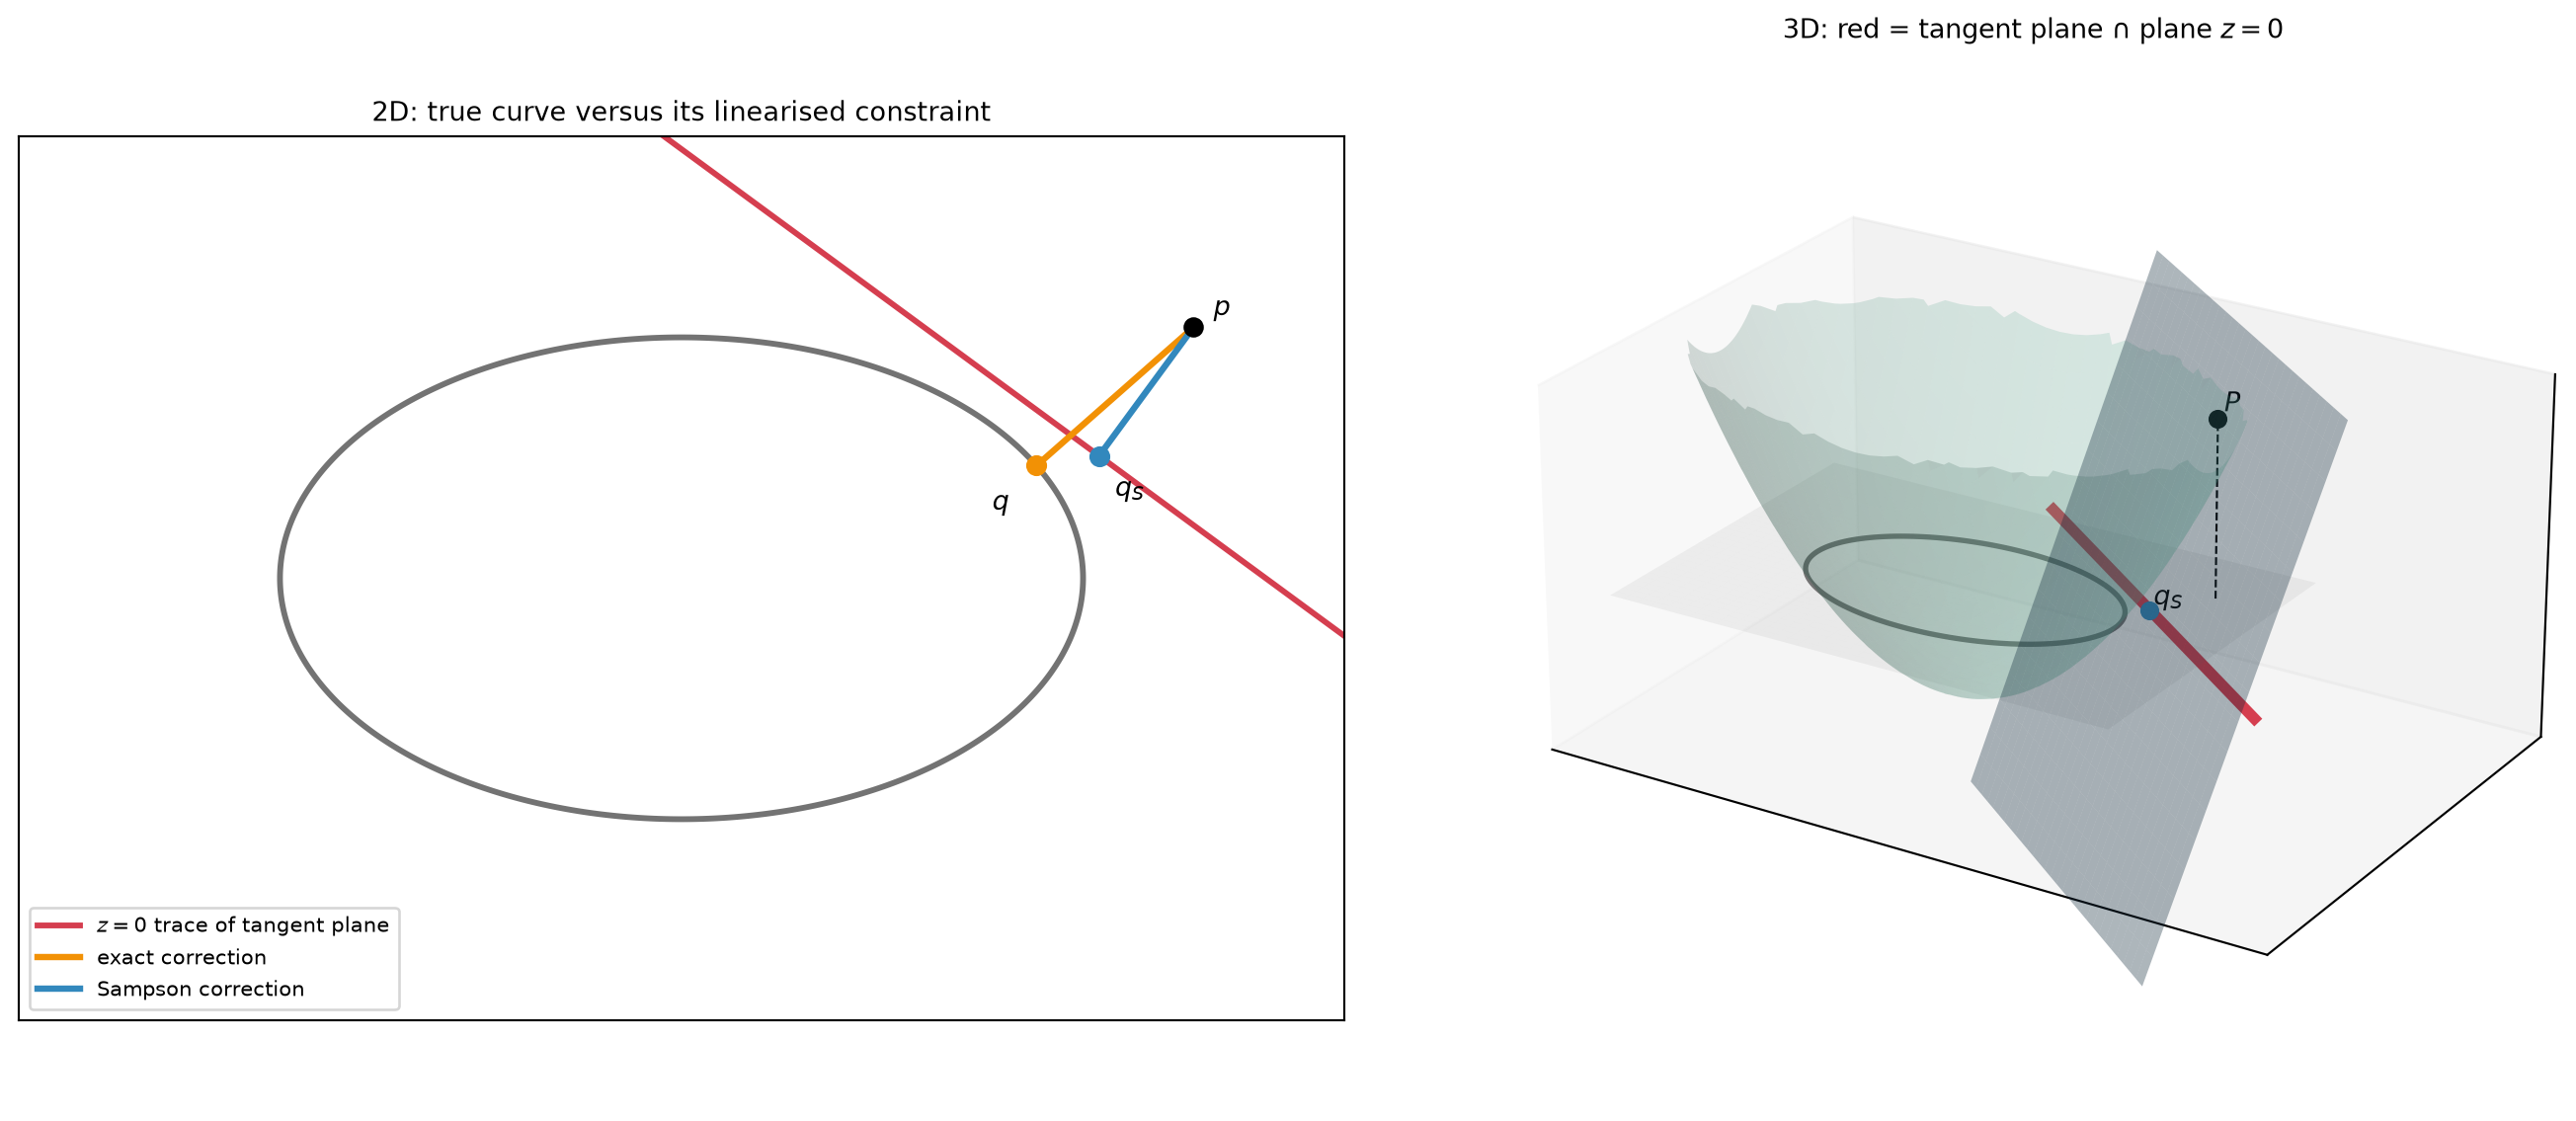

In [13]:
#| echo: false
#| label: fig-sampson-conic-geometry
#| fig-cap: >-
#|   Exact and Sampson corrections for one measurement. Left: $\mathbf q$ is the closest point on
#|   the true conic, whereas $\mathbf q_S$ is the closest point on the linearised constraint. Right:
#|   for the lifted surface $z=f(x,y)$, the red line is exactly the intersection of the tangent
#|   plane at $P=(p_x,p_y,f(\mathbf p))$ with the plane $z=0$.
#| column: page
# A dimensionless ellipse keeps the 3D construction readable.
Cc = conic_matrix([1/2.0**2, 0, 1/1.2**2, 0, 0, -1.0])
p0 = np.array([2.55, 1.25])
q0 = closest_point(Cc, p0)
d0, qS0 = sampson_correction(Cc, p0)
f0 = conic_value(Cc, p0[None,:])[0]
g0 = conic_grad(Cc, p0[None,:])[0]
nhat = g0 / np.linalg.norm(g0)
tdir = np.array([-nhat[1], nhat[0]])

# qS0 is on the zero set of the tangent plane, by construction.
lin_check = f0 + g0 @ (qS0 - p0)
print(f"tangent-plane equation evaluated on q_S: {lin_check:.2e}")

fig = plt.figure(figsize=(14.2, 5.8), layout="constrained")

# 2D panel
ax = fig.add_subplot(1, 2, 1)
gx, gy, F = value_grid(Cc, (-3.3,3.3), (-2.2,2.2), 400)
ax.contour(gx, gy, F, levels=[0], colors=[GREY], linewidths=2.2)
sline = np.linspace(-3.0, 3.0, 120)
L = qS0[None,:] + sline[:,None]*tdir[None,:]
ax.plot(L[:,0], L[:,1], color=RED, lw=2.2, label=r"$z=0$ trace of tangent plane")
ax.plot([p0[0],q0[0]], [p0[1],q0[1]], color=ACCENT, lw=2.4, label="exact correction")
ax.plot([p0[0],qS0[0]], [p0[1],qS0[1]], color=BLUE, lw=2.4, label="Sampson correction")
ax.scatter(*p0, color="k", s=45, zorder=5)
ax.scatter(*q0, color=ACCENT, s=48, zorder=5)
ax.scatter(*qS0, color=BLUE, s=48, zorder=5)
ax.text(p0[0]+.10, p0[1]+.06, r"$p$")
ax.text(q0[0]-.22, q0[1]-.22, r"$q$")
ax.text(qS0[0]+.08, qS0[1]-.20, r"$q_S$")
ax.set_aspect("equal"); ax.set_xlim(-3.3,3.3); ax.set_ylim(-2.2,2.2)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("2D: true curve versus its linearised constraint", fontsize=10)
ax.legend(fontsize=8, loc="lower left")

# 3D panel
ax = fig.add_subplot(1, 2, 2, projection="3d")
x = np.linspace(-3.3,3.3,110); y = np.linspace(-2.2,2.2,110)
X,Y = np.meshgrid(x,y); G = np.stack([X,Y,np.ones_like(X)])
Z = np.einsum("ihw,ij,jhw->hw", G, Cc, G)
Zshow = np.where(np.abs(Z)<2.0, Z, np.nan)
ax.plot_surface(X, Y, Zshow, alpha=.20, color="#66C2A5", linewidth=0)
ax.plot_surface(X, Y, 0*X, alpha=.09, color="#999999", linewidth=0)
ax.contour(X, Y, Z, levels=[0], zdir="z", offset=0, colors=[GREY], linewidths=2)

# Parameterise the tangent plane in coordinates aligned with the intersection.
# x(s,u) = q_S + s t + u n  ==>  z(s,u) = ||grad f|| u.
s = np.linspace(-2.7, 2.7, 30)
u = np.linspace(-1.15, 1.15, 20)
S,U = np.meshgrid(s,u)
Xp = qS0[0] + S*tdir[0] + U*nhat[0]
Yp = qS0[1] + S*tdir[1] + U*nhat[1]
Zp = np.linalg.norm(g0)*U
ax.plot_surface(Xp, Yp, Zp, alpha=.34, color=BLUE, linewidth=0)

# u=0 is simultaneously on the tangent plane and on z=0: draw that exact intersection.
L3 = qS0[None,:] + sline[:,None]*tdir[None,:]
ax.plot(L3[:,0], L3[:,1], np.zeros(len(L3)), color=RED, lw=4.2)

ax.scatter([p0[0]], [p0[1]], [f0], color="k", s=38)
ax.scatter([qS0[0]], [qS0[1]], [0], color=BLUE, s=38)
ax.plot([p0[0],p0[0]], [p0[1],p0[1]], [0,f0], "k--", lw=.8)
ax.text(p0[0]+.08, p0[1], f0+.08, r"$P$")
ax.text(qS0[0]+.05, qS0[1], .06, r"$q_S$")
ax.set_zlim(-1.5,2.0); ax.view_init(24,-58); ax.set_box_aspect((4.2,2.8,2.0))
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
ax.set_title(r"3D: red = tangent plane $\cap$ plane $z=0$", fontsize=10)

plt.show()

The two panels now encode exactly the same construction. The exact residual goes from $\mathbf p$ to the closest point $\mathbf q$ on the curved zero set. Sampson goes from $\mathbf p$ to $\mathbf q_S$ on the zero set of the **linearised** constraint.

When $\mathbf p$ is close to a regular part of the conic, the red line approximates the conic locally and $|r_S|$ is usually close to $r_G$. The approximation deteriorates when curvature matters over the size of the correction. If $\nabla f(\mathbf p)=0$, the linearised equation contains no directional information at all and the Sampson denominator vanishes.

## From DLT to geometric refinement

We can now use the usual recipe of geometric estimation:

1. use a linear method to get close;
2. refine the model with a residual that has a geometric meaning.

Let us take noisy points from a visible arc of the ellipse. DLT gives the initial conic. Then we run Levenberg–Marquardt on the vector of signed Sampson residuals $r_S$.

In [14]:
def arc(span_deg, n=70, seed=4, sigma=SIGMA):
    rng=np.random.default_rng(seed)
    t=np.linspace(0,np.deg2rad(span_deg),n)
    Q=np.column_stack([A_TRUE*np.cos(t),B_TRUE*np.sin(t)])
    return Q+rng.normal(0,sigma,Q.shape)


def refine_sampson(C0, P):
    v0=conic_vector(C0)
    def objective(v):
        v=v/np.linalg.norm(v)
        return sampson_residual(conic_matrix(v),P)
    res=least_squares(objective,v0,method="lm",xtol=1e-12,ftol=1e-12,gtol=1e-12,max_nfev=2000)
    v=res.x/np.linalg.norm(res.x)
    C=conic_matrix(v)
    return C/np.linalg.norm(C),res

Pnoisy=arc(120)
Cdlt=fit_dlt(Pnoisy)
Cref,res=refine_sampson(Cdlt,Pnoisy)

print(f"{'model':12s}{'type':>12s}{'semi-axes [px]':>24s}{'RMS |r_S| [px]':>18s}{'RMS r_G [px]':>16s}")
for name,C in [("DLT",Cdlt),("refined",Cref),("truth",C_TRUE)]:
    axes=conic_axes(C)
    atxt="-" if axes is None else f"{axes[0]:.1f}, {axes[1]:.1f}"
    rs=np.sqrt(np.mean(sampson_residual(C,Pnoisy)**2))
    rg=np.sqrt(np.mean(geometric_residual(C,Pnoisy)**2))
    print(f"{name:12s}{conic_type(C):>12s}{atxt:>24s}{rs:18.3f}{rg:16.3f}")

model               type          semi-axes [px]    RMS |r_S| [px]    RMS r_G [px]
DLT              ellipse            194.8, 115.8             0.996           0.995
refined          ellipse            199.4, 120.4             0.991           0.990
truth            ellipse            200.0, 120.0             1.011           1.011


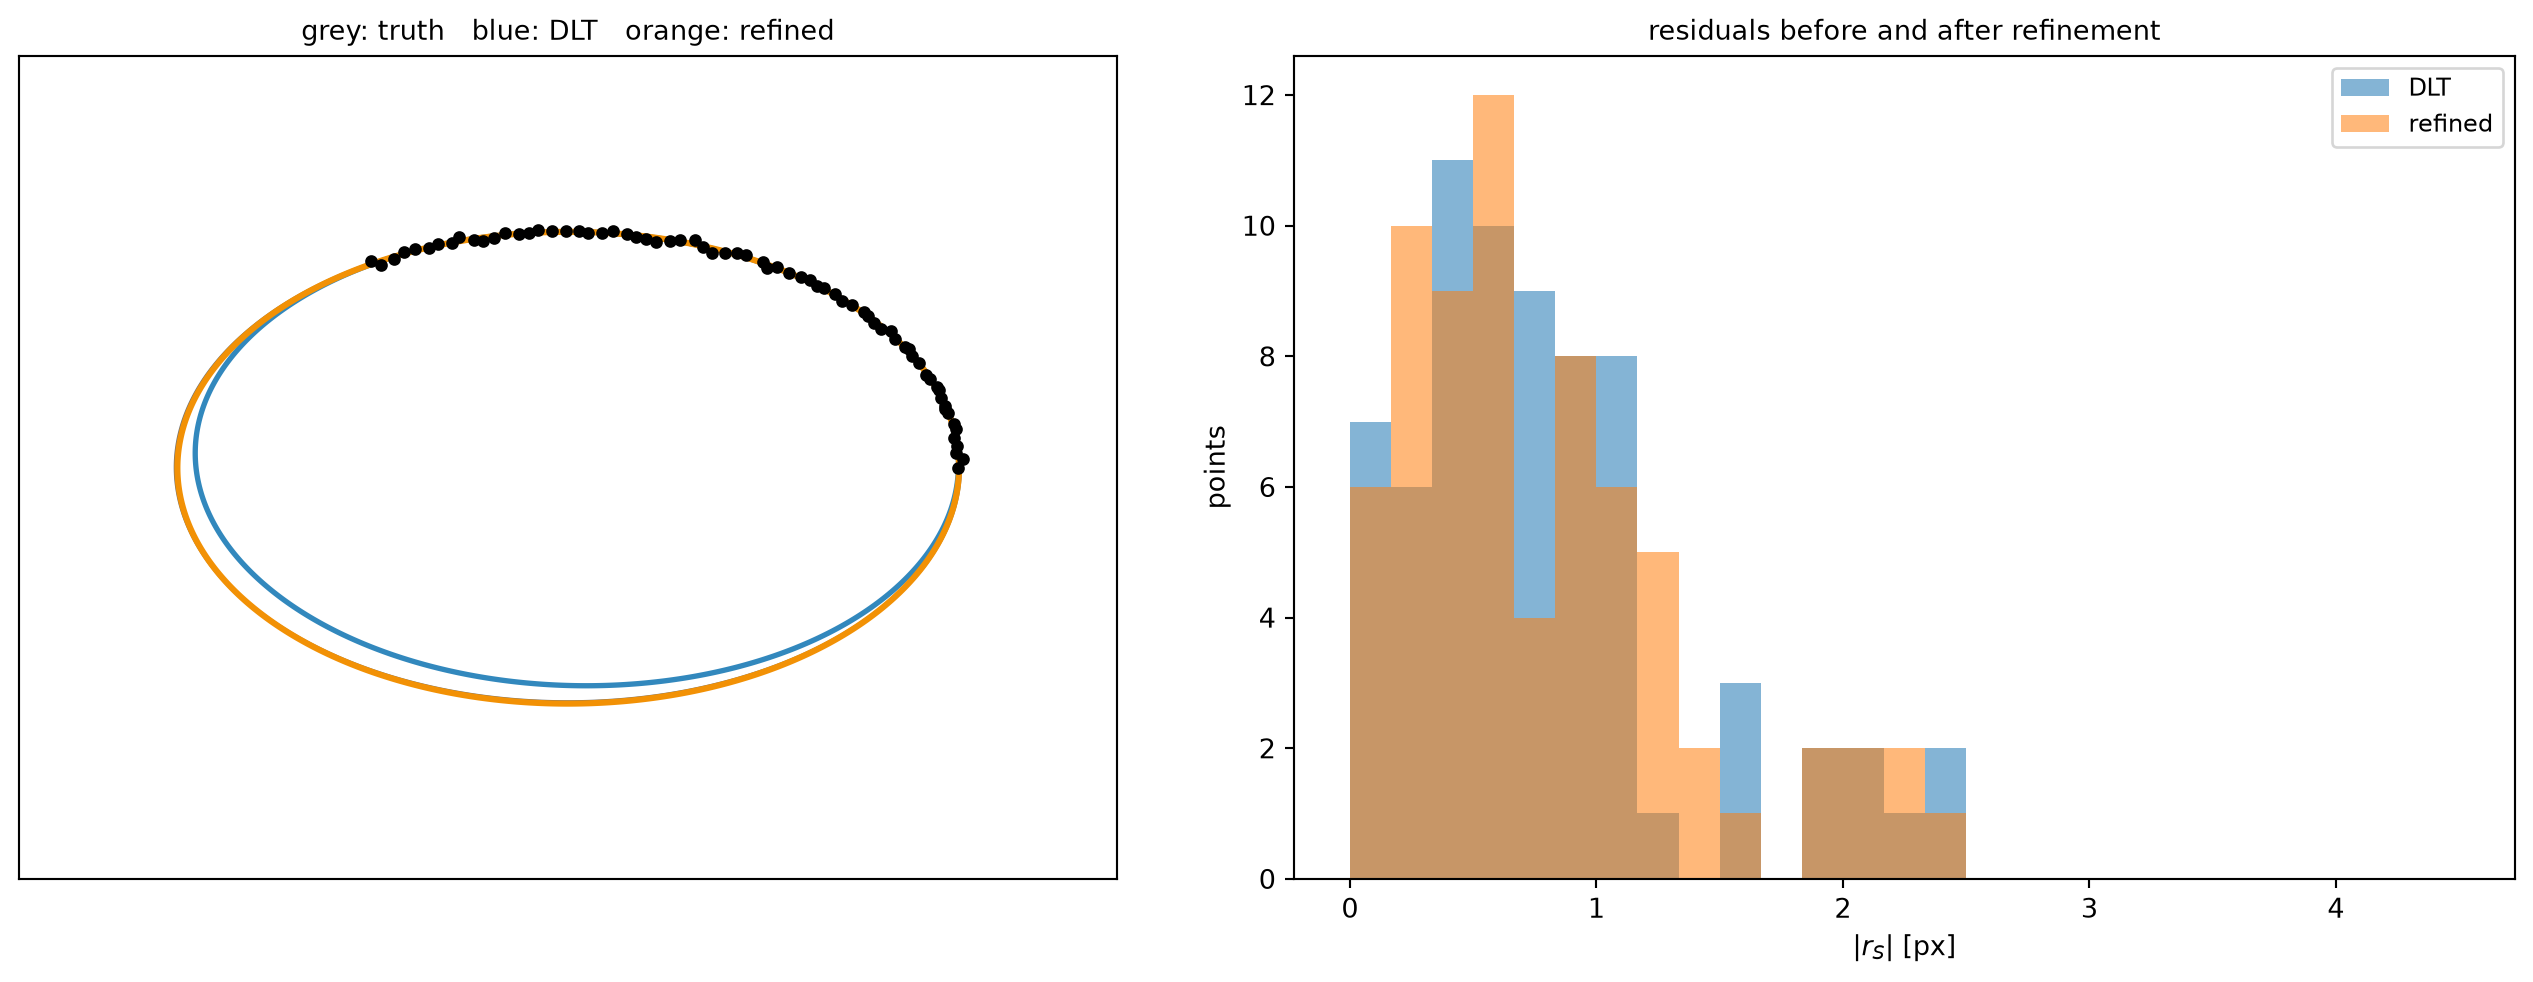

In [15]:
#| echo: false
#| label: fig-conic-refinement
#| fig-cap: >-
#|   From linear estimation to geometric refinement. Left: the DLT estimate and the conic obtained
#|   by Levenberg--Marquardt on the signed Sampson residual. Right: the distribution of $|r_S|$ on
#|   the noisy measurements before and after refinement.
#| column: page
fig,axes=plt.subplots(1, 2, figsize=(13.4, 5.0), layout="constrained")
gx,gy,_=value_grid(C_TRUE,*LIM)
for C,col,lw,label in [(C_TRUE,GREY,1.7,"truth"),(Cdlt,BLUE,2.0,"DLT"),(Cref,ACCENT,2.3,"Sampson refinement")]:
    _,_,F=value_grid(C,*LIM)
    axes[0].contour(gx,gy,F,levels=[0],colors=[col],linewidths=lw)
axes[0].scatter(Pnoisy[:,0],Pnoisy[:,1],s=14,color="k",zorder=5)
axes[0].set_aspect("equal"); axes[0].set_xlim(*LIM[0]); axes[0].set_ylim(*LIM[1])
axes[0].set_xticks([]); axes[0].set_yticks([])
axes[0].set_title("grey: truth   blue: DLT   orange: refined",fontsize=10)

bins=np.linspace(0,4.5,28)
axes[1].hist(np.abs(sampson_residual(Cdlt,Pnoisy)),bins=bins,alpha=.55,label="DLT")
axes[1].hist(np.abs(sampson_residual(Cref,Pnoisy)),bins=bins,alpha=.55,label="refined")
axes[1].set_xlabel(r"$|r_S|$ [px]"); axes[1].set_ylabel("points")
axes[1].legend(fontsize=9); axes[1].set_title("residuals before and after refinement",fontsize=10)
plt.show()

The DLT estimate is valuable because it gives us a good model in one SVD. The nonlinear stage is valuable because it can optimise a residual expressed in the units of the data.

This distinction will come back repeatedly. The linear equations are often the easiest way to **represent and initialise** a geometric problem; they do not automatically tell us which residual is appropriate for **measuring fit**.

There is also an important limitation to remember. Changing the residual does not add information and does not impose a conic type. If a short, noisy arc is compatible with both an ellipse and a hyperbola, Sampson refinement alone cannot decide that the answer ought to be an ellipse. Model constraints and residual design are different issues.

## Going deeper: exact distance, evolutes, and ED degree

The geometric residual $r_G$ looks innocent in the picture from Section 3, but computing it exactly already requires a nonlinear problem for every point.

Write

$$
\mathsf C=
\begin{bmatrix}
\mathsf A & \mathbf b\\
\mathbf b^\top & c
\end{bmatrix},
\qquad
f(\mathbf q)=\mathbf q^\top\mathsf A\mathbf q+2\mathbf b^\top\mathbf q+c.
$$

To find **all** stationary distances from $\mathbf p$ to the conic, minimise

$$
\frac12\|\mathbf q-\mathbf p\|^2
\quad\text{subject to}\quad f(\mathbf q)=0.
$$

The Lagrange equations are

$$
\mathbf q-\mathbf p+\mu(\mathsf A\mathbf q+\mathbf b)=0,
$$

so

$$
\mathbf q=(\mathsf I+\mu\mathsf A)^{-1}(\mathbf p-\mu\mathbf b).
$$

After diagonalising $\mathsf A$, substituting this expression back into $f(\mathbf q)=0$, and clearing denominators, we obtain a **quartic polynomial in $\mu$** for a non-circular ellipse. Each root gives a critical point of the distance. The geometric residual $r_G$ uses only the closest real one.

The important word here is *critical*. A nearest point is one critical point, but there can also be a farthest point and other stationary points. Geometrically, every critical point $\mathbf q$ satisfies

$$
\mathbf p-\mathbf q\ \parallel\ \nabla f(\mathbf q),
$$

so the line from $\mathbf q$ to $\mathbf p$ is a **normal to the ellipse**.

### Bonus: the evolute of an ellipse and the number of critical points

So the real critical points are the feet of the normals through $\mathbf p$, and
the question becomes: how many normals to an ellipse pass through a given point?
Four, or two — and it cannot be anything else, nor can it change arbitrarily.
Complex roots of a real polynomial come in conjugate pairs, so a root turns real
only by *meeting another one*. Wherever the count changes, two critical points
have collided.

Two feet of normals collide when the two normals coincide, and the point where
consecutive normals of a curve meet is its **centre of curvature** — the centre
of the circle that best fits the curve there. The boundary is therefore not a
curve we get to choose: it is forced to be the locus of centres of curvature.

For the ellipse $\mathbf q(t) = (a\cos t, b\sin t)$ with $a > b$, that locus is
the **evolute**, equivalently the envelope of the normal lines:

$$
\mathbf e(t)=
\left(
\frac{a^2-b^2}{a}\cos^3t,
\frac{b^2-a^2}{b}\sin^3t
\right).
$$

For a generic point **outside** the evolute a non-circular ellipse has two real
distance-critical points; for a generic point **inside**, four. On the evolute
itself the problem is non-generic, because two critical points have merged.

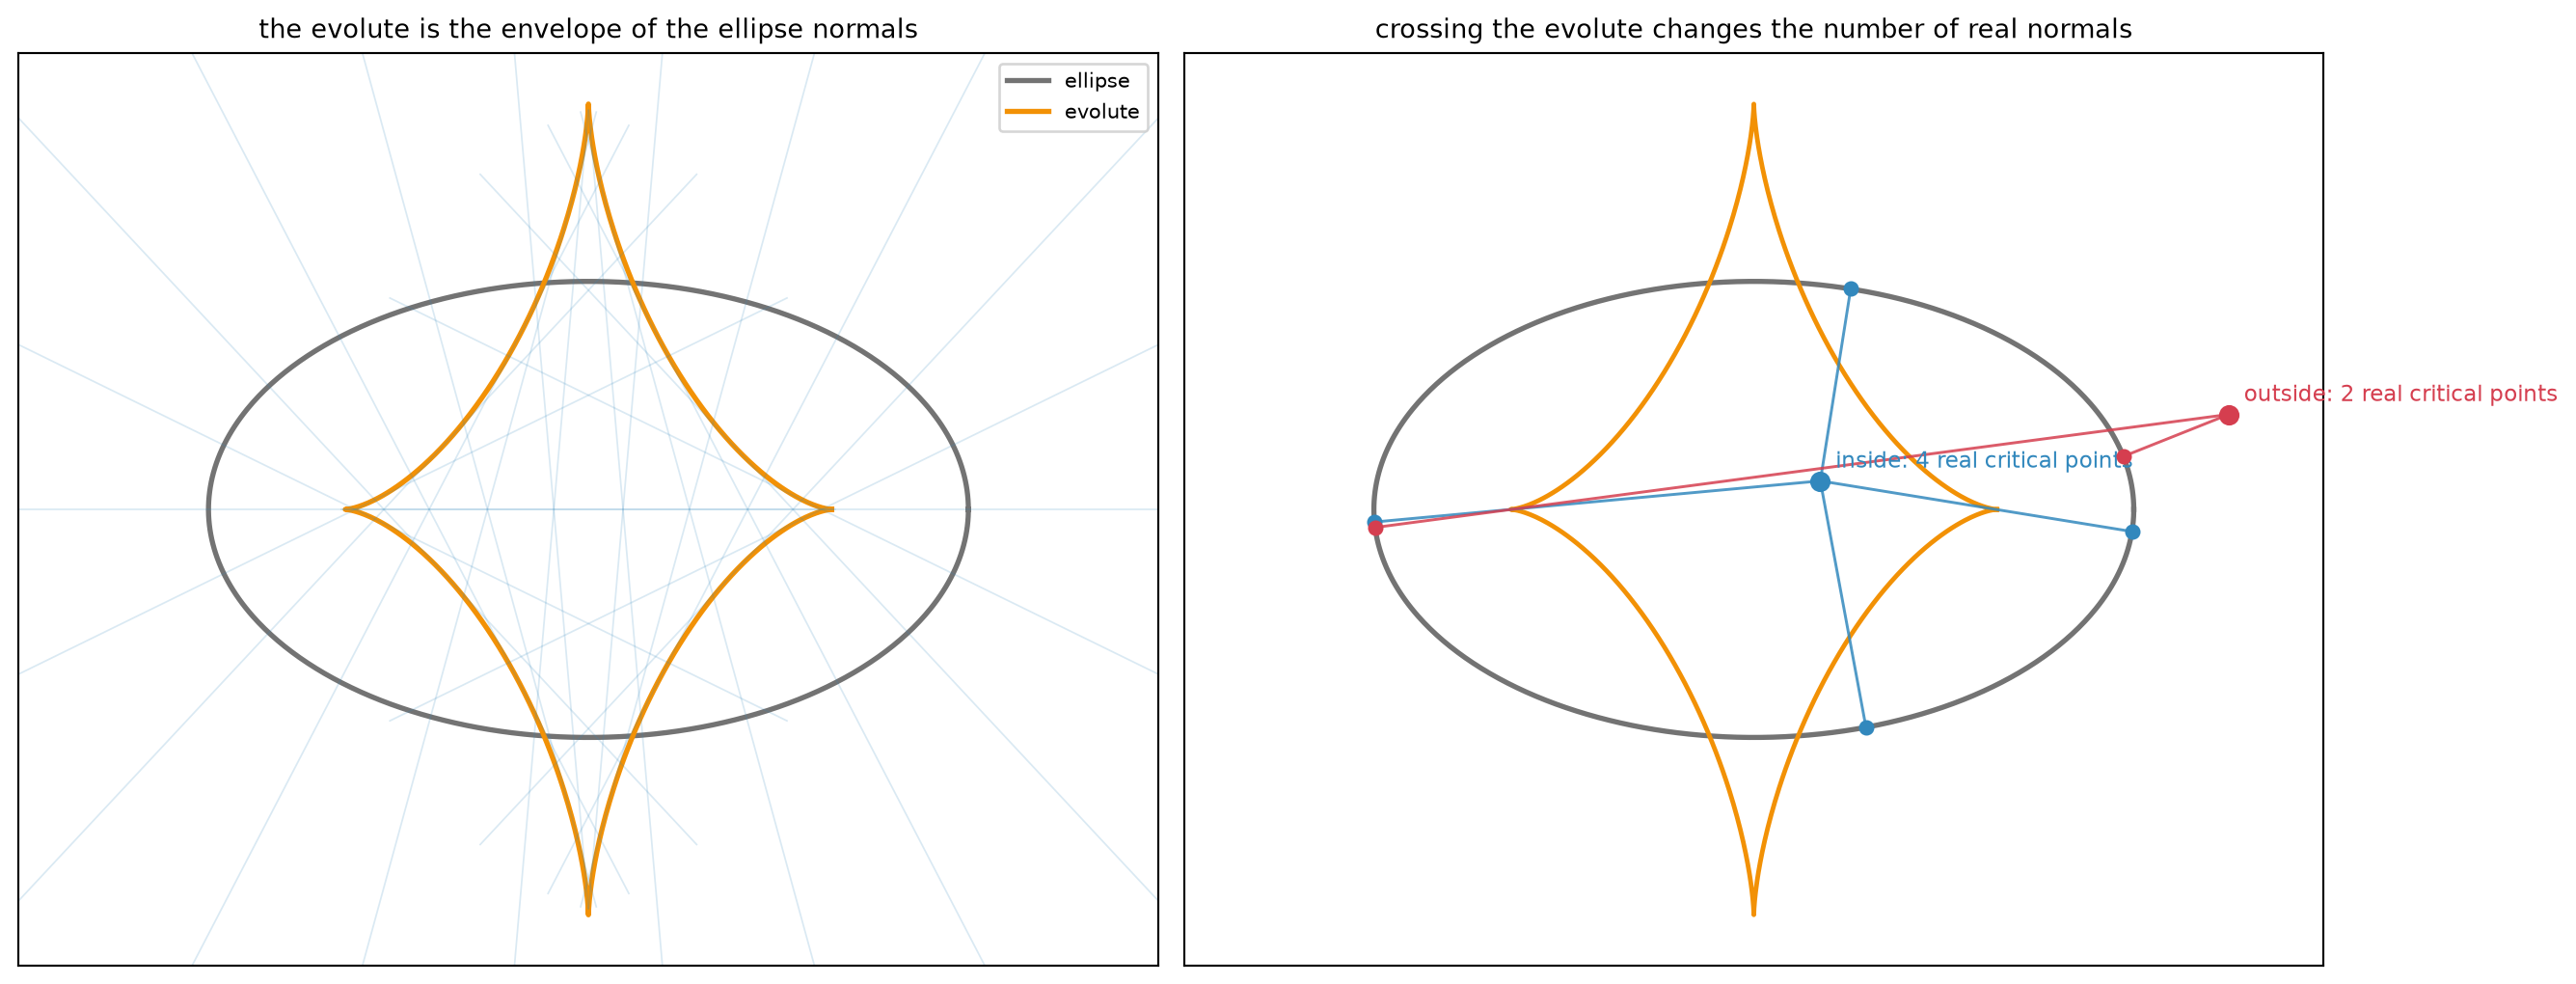

real critical points, inside evolute : 4
real critical points, outside evolute: 2


In [16]:
#| echo: false
#| label: fig-ellipse-evolute
#| fig-cap: >-
#|   The evolute and the exact Euclidean-distance problem for an ellipse. Left: the evolute is the
#|   envelope of the ellipse normals. Right: a generic point inside the evolute has four real
#|   distance-critical points, while a generic point outside has two.
#| column: page
def ellipse_evolute(a, b, t):
    return np.column_stack([
        (a*a-b*b)/a * np.cos(t)**3,
        (b*b-a*a)/b * np.sin(t)**3
    ])

te = np.linspace(0, 2*np.pi, 600)
E = ellipse_evolute(A_TRUE, B_TRUE, te)
Qell = np.column_stack([A_TRUE*np.cos(te), B_TRUE*np.sin(te)])

p_inside = np.array([35.0, 15.0])
p_outside = np.array([250.0, 50.0])
Qi = critical_points(C_TRUE, p_inside)
Qo = critical_points(C_TRUE, p_outside)

fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.4), layout="constrained")

# Left: evolute as envelope of normals.
ax = axes[0]
ax.plot(Qell[:,0], Qell[:,1], color=GREY, lw=2.0, label="ellipse")
ax.plot(E[:,0], E[:,1], color=ACCENT, lw=2.0, label="evolute")
for t0 in np.linspace(0, 2*np.pi, 22, endpoint=False):
    qn = np.array([A_TRUE*np.cos(t0), B_TRUE*np.sin(t0)])
    gn = conic_grad(C_TRUE, qn[None,:])[0]
    nn = gn/np.linalg.norm(gn)
    seg = np.stack([qn-330*nn, qn+330*nn])
    ax.plot(seg[:,0], seg[:,1], color=BLUE, lw=.65, alpha=.18)
ax.set_aspect("equal"); ax.set_xlim(-300,300); ax.set_ylim(-240,240)
ax.set_xticks([]); ax.set_yticks([]); ax.legend(fontsize=8, loc="upper right")
ax.set_title("the evolute is the envelope of the ellipse normals", fontsize=10)

# Right: real critical points for data inside/outside the evolute.
ax = axes[1]
ax.plot(Qell[:,0], Qell[:,1], color=GREY, lw=2.0)
ax.plot(E[:,0], E[:,1], color=ACCENT, lw=1.8)
for p0, Q0, col, lab in [(p_inside, Qi, BLUE, "inside: 4 real critical points"),
                          (p_outside, Qo, RED, "outside: 2 real critical points")]:
    ax.scatter(*p0, s=48, color=col, zorder=5)
    for q0 in Q0:
        ax.plot([p0[0],q0[0]], [p0[1],q0[1]], color=col, lw=1.1, alpha=.85)
        ax.scatter(*q0, s=25, color=col, zorder=4)
    ax.text(p0[0]+8, p0[1]+7, lab, color=col, fontsize=8.5)
ax.set_aspect("equal"); ax.set_xlim(-300,300); ax.set_ylim(-240,240)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("crossing the evolute changes the number of real normals", fontsize=10)

plt.show()

print("real critical points, inside evolute :", len(Qi))
print("real critical points, outside evolute:", len(Qo))

### What is the Euclidean distance degree?

This gives a concrete way to understand a piece of algebraic geometry without needing much algebraic geometry.

Take an algebraic model $X$ and a data point $\mathbf p$. Restrict the squared Euclidean distance

$$
d_{\mathbf p}(\mathbf q)=\|\mathbf q-\mathbf p\|^2
$$

to points $\mathbf q\in X$, and write the stationarity equations. For a curve, they say

$$
\mathbf q\in X,
\qquad
\mathbf p-\mathbf q\perp T_{\mathbf q}X.
$$

Now count how many solutions this system has for a **generic** data point. To obtain a number that is stable as the data move, algebraic geometry counts the solutions over $\mathbb C$, with multiplicity. That number is the **Euclidean distance degree**, or **ED degree**, of the model.

So ED degree is not the degree of the curve and it does not count nearest points. It measures the algebraic complexity of the *nearest-point problem*: how many stationary candidates the exact distance equations generically produce before we choose the closest real one.

For our non-circular ellipse the stationarity equation is quartic, and a generic data point has four complex critical points:

$$
\boxed{\operatorname{EDdegree}(\text{ellipse})=4.}
$$

The evolute explains why a real plot may show only two of them. Outside the evolute, two critical points are real and the other two are complex. Inside, all four are real. The ED degree remains four because the complex count is the stable one. On the evolute two solutions collide: this is exactly the exceptional locus where the generic counting picture changes.

This is the useful intuition to carry to harder estimation problems:

> **ED degree asks how algebraically complicated exact Euclidean fitting is, before any approximation such as Sampson is introduced.**

A line has ED degree one because orthogonal projection is unique and linear. A circle has ED degree two (nearest and farthest radial points). A generic ellipse already has ED degree four. The geometry is still elementary, but the exact fitting problem has become algebraically richer.

## Questions to leave open

- What happens to the pencil if the four points are not in general position? Which rank drops are possible, and what do they mean geometrically?
- The Sampson residual is invariant to rescaling $\mathsf C$. Is it also invariant to an arbitrary rescaling of the image coordinates?
- The direction of $\nabla f$ is geometric, but its magnitude depends on the chosen implicit equation. Which combinations of $f$ and $\nabla f$ survive a rescaling $f\mapsto\alpha f$?
- The evolute marks where two distance-critical points collide. What would the analogous exceptional set look like for a more complicated geometric model?
- If the application tells us in advance that the conic must be an ellipse, where should that knowledge enter: in the residual or in the model parametrisation?
- How would the fitting pipeline change in the presence of outliers? Which residual would you give to RANSAC or MSAC?

## Further reading

- Sampson, P. D. “Fitting conic sections to very scattered data: an iterative refinement of the Bookstein algorithm”, *Computer Graphics and Image Processing* 18(1), 1982. The original conic-fitting setting of the approximation.
- Harker, M. and O'Leary, P. “First order geometric distance (the myth of Sampsonus)”, *BMVC*, 2006. The precise distinction between distance to a linearised curve and a first-order approximation of the distance itself.
- Bookstein, F. L. “Fitting conic sections to scattered data”, *Computer Graphics and Image Processing* 9(1), 1979.
- Taubin, G. “Estimation of planar curves, surfaces and nonplanar space curves defined by implicit equations”, *IEEE TPAMI* 13(11), 1991.
- Fitzgibbon, A., Pilu, M. and Fisher, R. “Direct least square fitting of ellipses”, *IEEE TPAMI* 21(5), 1999.
- Draisma, J., Horobet, E., Ottaviani, G., Sturmfels, B. and Thomas, R. “The Euclidean distance degree of an algebraic variety”, *Foundations of Computational Mathematics* 16, 2016. ED degree, ED discriminants, and the ellipse/evolute example.
- Hartley, R. and Zisserman, A. *Multiple View Geometry in Computer Vision*, 2nd ed., Cambridge University Press, 2004.

---

**Luca Magri** — Computer Vision Dojo  
Code MIT · text and figures CC BY-NC-ND 4.0  
<https://magrilu.github.io/cv-dojo/>